# Distance to TLS and bronchi
In this notebook, we calculate set up distance axes: distance to TLS and distance to bronchi zone. Here we include the interior distance in the TLS as negative values. 

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import time
import warnings
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq


import scipy
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
from scipy import stats
import scipy.ndimage as ndi
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

from shapely.geometry import Point

from shapely.geometry import MultiPolygon
from alphashape import alphashape
from alphashape import optimizealpha
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

import pickle
import joblib

import random
import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter(action='ignore', category=Warning)

sys.version_info

sys.version_info(major=3, minor=12, micro=2, releaselevel='final', serial=0)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
dist_out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis/distance")


plot_out_dir = os.path.join(dist_out_dir, 'plots')

print(inputs_dir)
print(dist_out_dir)

/home/workspace/spatial_tls_manuscript/inputs
/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import plotting_utils as pu
import de_utils as du

In [4]:
importlib.reload(du)

<module 'de_utils' from '/home/workspace/spatial_tls_manuscript/utils/de_utils.py'>

## Load adata

In [5]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'))

## Load palettes

In [5]:
with open(os.path.join(inputs_dir, '20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [6]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

# Distances
- Try two approaches:
- (1) distance to tls, bronchi, or vessel zone (not structure). Cells in zone = 0
- (2) distance to tls or bronchi structure

In [ ]:
def cell_dist_to_zone(adata, cell_type_col, zone_col, zone_label, nearest_n, dist_col):
    
    # get coordinates of other cell type (the one we want to calculate the distance to)
    adata_other_type = adata[adata.obs[zone_col] == zone_label, :]
    zone_label_coords = adata_other_type.obs[['x_centroid', 'y_centroid']].values
    print('adata_other_type shape ', adata_other_type.shape)

    # first set all cells in adata with zone_col == zone_label to 0
    adata.obs.loc[adata.obs[zone_col] == zone_label, dist_col] = 0
    # now only calculate distances for other zones
    adata_other_zones = adata[adata.obs[zone_col] != zone_label, :]
    
    # Iterate over each unique cell type
    for cell_type in adata_other_zones.obs[cell_type_col].unique():

        # Filter AnnData object for the current cell type
        adata_filtered = adata_other_zones[adata_other_zones.obs[cell_type_col] == cell_type, :]
        adata_filtered_cell_type_indices = adata_filtered.obs.index
        # print('adata_cell_type shape ', adata_filtered.shape)
    
        # Get the coordinates of the cells of the current type
        cell_type_coords = adata_filtered.obs[['x_centroid', 'y_centroid']].values
        
        # Calculate the pairwise distances between the current cell type and other cell type
        pairwise_distances = cdist(cell_type_coords, zone_label_coords, metric='euclidean')
    
        # Sort distances and select nearest n
        nearest_distances = np.sort(pairwise_distances, axis=1)[:, :nearest_n]
        
        # Calculate the average distance to the nearest n cells
        avg_distance = np.mean(nearest_distances, axis=1)

        # Store distances in adata.obs 
        
        # Assigning values to the new column in the original DataFrame, using cell type filtered adata indices
        adata.obs.loc[adata_filtered_cell_type_indices, dist_col] = avg_distance

    return adata

In [ ]:
import numpy as np
from shapely.geometry import Point, Polygon, MultiPolygon
from tqdm import  tqdm

def calculate_distances_to_regions(adata, dist_out_dir):
    """
    Calculate distances from each cell to the closest TLS and bronchi regions.
    Also determine if cells are inside these regions.
    
    Parameters
    ----------
    adata : AnnData
        The AnnData object containing spatial coordinates of cells
    dist_out_dir : str
        Directory where polygon files are stored
    
    Returns
    -------
    adata : AnnData
        Updated AnnData object with distance and boolean columns
    """
    # Create new columns in adata.obs for storing distances and boolean flags
    adata.obs['distance_to_tls'] = np.nan
    adata.obs['distance_to_bronchi'] = np.nan
    adata.obs['inside_tls'] = False
    adata.obs['inside_bronchi'] = False
    
    # Process each sample separately
    for sample_label in adata.obs['sample_label'].cat.categories:
        print(f"Processing sample: {sample_label}")
        
        # Get cells for current sample
        sample_mask = adata.obs['sample_label'] == sample_label
        
        # Load TLS polygons for this sample
        tls_poly_path = os.path.join(dist_out_dir, f'tls_poly_{sample_label}.pkl')
        tls_poly = joblib.load(tls_poly_path)
        
        # Load bronchi polygons for this sample
        bronchi_poly_path = os.path.join(dist_out_dir, f'bronchi_poly_{sample_label}.pkl')
        bronchi_poly = joblib.load(bronchi_poly_path)
        
        # Get spatial coordinates for cells in this sample
        coords = adata[sample_mask].obsm['spatial']
        
        # Calculate distances and check if cells are inside regions
        distances_to_tls = []
        distances_to_bronchi = []
        inside_tls_flags = []
        inside_bronchi_flags = []
        
        for i, (x, y) in tqdm(enumerate(coords), total=len(coords), desc=f"Processing {sample_label}", ncols=100):
            # Create point for current cell
            point = Point(x, y)
            
            # Check TLS regions
            min_dist_tls = float('inf')
            is_inside_tls = False
            
            # Handle potential MultiPolygon case
            if isinstance(tls_poly, MultiPolygon):
                tls_polygons = list(tls_poly.geoms)
            else:
                tls_polygons = [tls_poly]
                
            for poly in tls_polygons:
                # Check if point is inside polygon
                if poly.contains(point):
                    min_dist_tls = 0
                    is_inside_tls = True
                    break
                # Calculate distance to polygon if not inside
                dist = point.distance(poly)
                if dist < min_dist_tls:
                    min_dist_tls = dist
            
            # Check bronchi regions
            min_dist_bronchi = float('inf')
            is_inside_bronchi = False
            
            # Handle potential MultiPolygon case
            if isinstance(bronchi_poly, MultiPolygon):
                bronchi_polygons = list(bronchi_poly.geoms)
            else:
                bronchi_polygons = [bronchi_poly]
                
            for poly in bronchi_polygons:
                # Check if point is inside polygon
                if poly.contains(point):
                    min_dist_bronchi = 0
                    is_inside_bronchi = True
                    break
                # Calculate distance to polygon if not inside
                dist = point.distance(poly)
                if dist < min_dist_bronchi:
                    min_dist_bronchi = dist
            
            distances_to_tls.append(min_dist_tls)
            distances_to_bronchi.append(min_dist_bronchi)
            inside_tls_flags.append(is_inside_tls)
            inside_bronchi_flags.append(is_inside_bronchi)
        
        # Update AnnData object with calculated values for this sample
        adata.obs.loc[sample_mask, 'distance_to_tls'] = distances_to_tls
        adata.obs.loc[sample_mask, 'distance_to_bronchi'] = distances_to_bronchi
        adata.obs.loc[sample_mask, 'inside_tls'] = inside_tls_flags
        adata.obs.loc[sample_mask, 'inside_bronchi'] = inside_bronchi_flags
        
    return adata

In [ ]:
for zone_label in ['bronchi', 'vessels', 'TLS']:
    cell_type_col = 'label_fine'
    zone_col = 'zone_consol'
    dist_col = f'avg_distance_to_{zone_label}_zone'
    nearest_n = 10 
    
    start_time = time.time()
    
    adata.obs[dist_col] = np
    
    for sample_label in adata.obs['sample_label'].cat.categories:
        
        print(sample_label)
    
        adata_sample = adata[adata.obs['sample_label']==sample_label, :]
        
        # run distance calculation for each sample 
        adata_sample = cell_dist_to_zone(adata=adata_sample, 
                                                   cell_type_col=cell_type_col, 
                                                   zone_col=zone_col, 
                                                   zone_label=zone_label, 
                                                   nearest_n=nearest_n, 
                                                   dist_col=dist_col)
        
        # get distance df for each structure and add it back to the main adata object
        dist_df = adata_sample.obs[[dist_col]] 
        adata.obs.loc[dist_df.index, dist_col] = dist_df[dist_col]
    
    adata.obs[dist_col] = pd.to_numeric(adata.obs[dist_col])
    end_time = time.time()
    elapsed_time = (end_time - start_time) / 60
    print(elapsed_time, ' min')

calculate_distances_to_regions(adata, dist_out_dir)

# adata.write_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'), compression='gzip')

# Plot distances

In [ ]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'))

In [8]:
# matplotlib settings
plt.rcdefaults()
mpl.rcParams['pdf.fonttype'] = 42

In [ ]:
import scvelo as scv
def scvelo_heatmap(
    adata: sc.AnnData,
    sample_label: list[str],
    sortby: str,
    key_name: str,
    key_value: str = None,
    highlight: list[str] = None,
    n_bins: int = 5,
    col_color = None, 
    x_clip = None,
    expression_threshold = None, 
    figsize: tuple = None 
):
    """
    Create a heatmap to visualize gene expression trends in single-cell RNA-seq data,
    with options for subsetting, sorting, and highlighting genes.

    Parameters:
    - adata (sc.AnnData): Annotated data object containing single-cell RNA-seq data.
    - sample_label (List[str]): List of batch identifiers to subset the data.
    - key_name (str): String representing the key in `adata.obs` to use for subsetting cells.
    - key_value (str): String representing the value of `key_name` to subset to.
    - sortby (str): Variable to sort the heatmap by (e.g., "crypt_villi_axis").
    - highlight (List[str]): List of labels to highlight on the heatmap.
    - n_bins (int, optional): Integer specifying the number of bins to use for convolution (default: 5).

    Returns:
    - s (seaborn.matrix.ClusterGrid): Matplotlib figure object representing the heatmap.

    This function subsets the input data based on specified sample_labels and key-value pairs,
    filters genes expressed in a minimum percentage of cells, and creates a heatmap
    to visualize gene expression trends along a specified variable. The function also allows
    highlighting specific labels on the y-axis.
    """
    print("Creating Heatmap for sample labels ", " + ".join(sample_label))

    # Subset sample_label
    adata = adata[adata.obs["sample_label"].isin(sample_label)]
    if key_value:
        print(f"Subset to '{key_name}'=='{key_value}'")
        # Subset to key
        adata = adata[adata.obs[key_name] == key_value]
    else:
        print("using all cells")
        
    # Filter to include only genes that are expressed in 5% of the cells
    if expression_threshold:
        print('removing genes by expression threshold: ', expression_threshold, ' %')
        adata=filter_adata_expressed_in_n_cells(adata,percent=expression_threshold)
    else:
        adata = adata.copy()
    print('adata shape: ', adata.shape)

    # Clip x axis
    if x_clip:
        print('clipping x to ', x_clip)
        adata = adata[adata.obs[sortby] <= x_clip, :]
        # adata.obs.loc[adata.obs[sortby] > x_clip, sortby] = x_clip
        
    n_convolve = len(adata) // n_bins
    print(f"Setting `n_convolve` to {n_convolve} ({n_bins} bins, {len(adata)} cells) ")
    # Plot
    s = scv.pl.heatmap(
        adata,
        var_names=adata.var_names,
        sortby=sortby,
        n_convolve=n_convolve,
        show=False,
        yticklabels=True,
        rasterized=True,
        # color_map=colormap,
        color_map='viridis',
        col_color = col_color,
        figsize=figsize
        
    )
    ax = s.ax_heatmap

    # Loop through the x-axis tick labels and show/hide based on the 'highlight' list
    if highlight:
        for i, label in enumerate(ax.get_yticklabels()):
            if label.get_text() not in highlight:
                label.set_visible(False)
                ax.get_yticklines()[2 * i + 1].set_visible(False)
            ax.get_yticklines()[2 * i].set_visible(False)
    else:
        # Make sure all labels and ticks are visible
        for label in ax.get_yticklabels():
            label.set_visible(True)
    
        for tickline in ax.get_yticklines():
            tickline.set_visible(False)  # optional: hide all tick lines
        

    ax.set_xlabel("")
    ax.set_title("")
    return s

## Separate by sample timepoint 

In [ ]:
adata_d3 = adata[adata.obs['sample_label']=='HDM_day3', :]
adata_d30 = adata[adata.obs['sample_label']=='HDM_day30', :]

In [ ]:
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'avg_distance_to_bronchi_zone',
               vmax = 500)
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'distance_to_bronchi',
               vmax = 500)

In [ ]:
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'distance_to_tls', vmax = 500)
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'avg_distance_to_TLS_zone', vmax = 500)
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'tls_index')
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'zone_consol')

In [ ]:
sc.pl.embedding(adata_d3, basis = 'spatial', color = 'avg_distance_to_vessels_zone', vmax = 300)


## Plot CD4 DE genes along distance axes (in CD4 act only)

## First, make a quick colorbar

In [12]:
import matplotlib.cm as cm
# Define the colormap
cmap = cm.viridis  # or e.g., cm.viridis_r, cm.Reds, etc.

# Create a dummy scalar mappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(1, 4))  # adjust size as needed

# Add the colorbar to the axis
cb = fig.colorbar(sm, cax=ax)

# Remove ticks and labels
cb.ax.set_yticks([])
cb.ax.set_yticklabels([])

# Remove outline
cb.outline.set_visible(False)

# Save the figure
fig.savefig(os.path.join(plot_out_dir, "colormap_viridis_clean.png"), dpi=300, bbox_inches='tight', transparent=True)
plt.close(fig)

#### Filter genes by those robustly expressed in CITE dataset and in Xenium datast (5% threshold in at least one subset):

In [21]:
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv('/home/workspace/spatial_mouse_lung_outputs/distance_analysis/ouputs_mouselung_xenseg_HDM/R/cite_expressed_genes_by_annotation.csv')
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
# adata_cd4 = adata.copy()
adata_cd4 = adata[adata.obs['label_coarse']=='CD4 T cell', :].copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = du.filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection and use this list for heatmaps 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

In [ ]:
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca']
genes_highlight_bronchi = ['Il1rl1', 'Il2ra', 'Foxp3', 'Gata3', 'Klrg1', 'Nmur1', 'Prdm1', 'Cxcr6', 'Id3', 'Slamf6', 'Tcf7', 'Tbx21', 'Ccr7']

In [ ]:
for sample_label in adata.obs['sample_label'].cat.categories:
    print(sample_label)
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    s = scvelo_heatmap(
        adata_plot[:,genes_cite_xen_filt],
        sample_label=[sample_label],
        sortby = 'distance_to_tls',
        key_name = 'label_medium',
        key_value = 'CD4 act',
        highlight = genes_highlight_tls,
        x_clip = 450, 
        expression_threshold= None, # already using a filtered gene list 
        figsize=(5,6)
    )
    s
    plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls-structure_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
for sample_label in adata.obs['sample_label'].cat.categories:
    print(sample_label)
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    s = scvelo_heatmap(
        adata_plot[~adata_plot.obs['zone_consol'].isin(['TLS']),genes_cite_xen_filt],
        sample_label=[sample_label],
        sortby = 'avg_distance_to_bronchi_zone',
        key_name = 'label_medium',
        key_value = 'CD4 act',
        highlight = genes_highlight_bronchi,
        x_clip = 450, 
        expression_threshold= None, # already using a filtered gene list 
        figsize=(5,6)
    )
    s
    plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_bronchi-zone_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)

### Generate heatmaps showing all gene labels, just for day 3

In [ ]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
s = scvelo_heatmap(
    adata_plot[:,genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'distance_to_tls',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    highlight = None,
    x_clip = 500, 
    expression_threshold= None, # already using a filtered gene list 
    figsize=(5,25)
)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls-structure_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
s = scvelo_heatmap(
    adata_plot[~adata_plot.obs['zone_consol'].isin(['TLS']),genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'avg_distance_to_bronchi_zone',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    highlight = None,
    x_clip = 500, 
    expression_threshold= None, # already using a filtered gene list 
    figsize=(5,25)
)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_bronchi-zone_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)

## Plot cytokine ligand DE genes along distance axes (in all cells)

In [ ]:
# try cellphoneDB ligands instead of kegg cytokine ligands

df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands = df_lr['ligand'].tolist()
ligands_panel = list(set(ligands) & set(adata_d3.var.index))
len(ligands_panel) 

In [ ]:
# df_kegg_cytokines = pd.read_csv("/home/workspace/spatial_tls_manuscript/inputs/kegg_cytokines.csv")
# df_kegg_cytokines = df_kegg_cytokines[df_kegg_cytokines["type"] == "ligand"]

# all_cyto_genes = df_kegg_cytokines['gene'].tolist()

# cyto_genes_panel = list(set(all_cyto_genes) & set(adata_d3.var.index))
# len(cyto_genes_panel)

### All cytokine ligands in panel 

In [ ]:
s = scvelo_heatmap(
    # adata_d3[:,cyto_genes_panel],
    adata_d3[:,ligands_panel],
    sample_label=['HDM_day3'],
    sortby = 'distance_to_tls',
    key_name = 'label_medium',
    key_value = None,
    highlight = None,
    x_clip = 450,
    expression_threshold= 0.05,
    figsize=(5,4)
)
s
# plt.savefig(os.path.join(plot_out_dir, "HDM_day3_scVelo_tls-structure_allcells_cyto.pdf"), dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(os.path.join(plot_out_dir, "HDM_day3_scVelo_tls-structure_allcells_cellphoneDBligands.pdf"), dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
s = scvelo_heatmap(
    # adata_d3[:,cyto_genes_panel],
    adata_d3[:,ligands_panel],
    sample_label=['HDM_day3'],
    sortby = 'avg_distance_to_bronchi_zone',
    key_name = 'label_medium',
    key_value = None,
    highlight = None,
    x_clip = 450,
    expression_threshold= 0.05,
    figsize=(5,4)
)
s
plt.savefig(os.path.join(plot_out_dir, "HDM_day3_scVelo_bronchi_allcells_cellphoneDBligands.pdf"), dpi=300, bbox_inches='tight', transparent=True)

# Define categories based on TLS and bronchi proximity

### Gate cell subsets by spatial region (2D distance density)

Plot the 2D distance density of a chosen `label_fine` (or `label_medium`) subset, overlay rectangular **gates**, iterate on the gate bounds, then apply the final gates to write a `spatial_region` column to `adata.obs`.

- `plot_celltype_density_2d(...)` — KDE density of one cell subset over (bronchi-distance, TLS-distance), with gates drawn on top.
- `assign_spatial_region(...)` — applies the same gates to label every cell with its region.

In [7]:
# Use a version where instead of all cells in TLS = 0, use the radial distance in/out
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure_tls_dist_categories.h5ad'))

In [8]:
def update_tls_distances(adata, inplace=True):
    """
    Updates 'distance_to_tls' for cells inside a TLS (d == 0) by replacing it 
    with (max_radial_distance - current_radial_distance) within each unique TLS.
    
    """
    # Handle inplace vs copy
    if not inplace:
        adata = adata.copy()
    
    # Identify the cells within TLS (d == 0) specifically within this subset
    inTLS_idx = adata.obs.index[adata.obs['distance_to_tls'] == 0]
    
    # Calculate tls_radial_dist_neg grouped by 'tls_index'
    max_dist_per_tls = adata.obs.groupby('tls_index')['tls_radial_dist'].transform('max')
    tls_radial_dist_neg = - (max_dist_per_tls - adata.obs['tls_radial_dist'])
    
    # Apply the updates safely using .loc
    adata.obs.loc[inTLS_idx, 'distance_to_tls'] = tls_radial_dist_neg.loc[inTLS_idx]


    if not inplace:
        return adata

In [9]:
# make sure tls indices are unique
adata.obs['sample_tls_index'] = (adata.obs['sample'].astype(str)+adata.obs['tls_index'].astype(str)).astype('category')
len(adata.obs['tls_index'].unique())
len(adata.obs['sample_tls_index'].unique())

# update distance to tls to include negative distances inside tls
update_tls_distances(adata)

In [10]:
# import matplotlib.patches as mpatches


# def _draw_gates(ax, gates, x_clip, y_clip, show_labels=True, xlim=None, ylim=None):
#     """Overlay named rectangular gates on a 2D distance plot.

#     Each gate is {'x_min','x_max','y_min','y_max'} (any subset of keys), in RAW
#     distance units. Missing/None bounds default to the plot edges
#     (0 .. x_clip / y_clip).

#     Gate borders are drawn as four independent line segments. If `xlim` / `ylim`
#     (the view limits) are given, each border is drawn only where it lies within
#     the view: a border whose constant edge is outside the limits is omitted, and
#     borders running past an edge are clipped to it. This lets a gate whose bound
#     sits beyond the axis (e.g. y_min below the y-axis minimum) still draw its
#     in-view borders without a stray line off the plot.
#     """
#     def _clip_seg(a, b, lo, hi):
#         """Clip the 1D segment spanning (a, b) to [lo, hi]; None if fully outside."""
#         s0, s1 = min(a, b), max(a, b)
#         s0, s1 = max(s0, lo), min(s1, hi)
#         return (s0, s1) if s0 <= s1 else None

#     for name, b in gates.items():
#         x0 = b.get('x_min') if b.get('x_min') is not None else 0
#         x1 = b.get('x_max') if b.get('x_max') is not None else x_clip
#         y0 = b.get('y_min') if b.get('y_min') is not None else 0
#         y1 = b.get('y_max') if b.get('y_max') is not None else y_clip

#         xlo, xhi = xlim if xlim is not None else (min(x0, x1), max(x0, x1))
#         ylo, yhi = ylim if ylim is not None else (min(y0, y1), max(y0, y1))

#         # Horizontal borders (bottom=y0, top=y1): draw only if the edge's y is
#         # within the y-view, clipped to the x-view.
#         for ty in (y0, y1):
#             if ylo <= ty <= yhi:
#                 seg = _clip_seg(x0, x1, xlo, xhi)
#                 if seg is not None:
#                     ax.plot([seg[0], seg[1]], [ty, ty],
#                             color='red', linestyle='-', linewidth=2)
#         # Vertical borders (left=x0, right=x1): draw only if the edge's x is
#         # within the x-view, clipped to the y-view.
#         for tx in (x0, x1):
#             if xlo <= tx <= xhi:
#                 seg = _clip_seg(y0, y1, ylo, yhi)
#                 if seg is not None:
#                     ax.plot([tx, tx], [seg[0], seg[1]],
#                             color='red', linestyle='-', linewidth=2)

#         if show_labels:
#             seg_x = _clip_seg(x0, x1, xlo, xhi)
#             seg_y = _clip_seg(y0, y1, ylo, yhi)
#             if seg_x is not None and seg_y is not None:
#                 # center the label on the VISIBLE portion of the gate
#                 ax.text((seg_x[0] + seg_x[1]) / 2, (seg_y[0] + seg_y[1]) / 2,
#                         name, ha='center', va='center', fontsize=8, color='black')


# def plot_celltype_density_2d(
#     adata: sc.AnnData,
#     sample_label: list[str],
#     celltype: str = None,
#     x_axis: str = 'avg_distance_to_bronchi_zone',
#     y_axis: str = 'distance_to_tls',
#     celltype_col: str = 'label_fine',
#     gates: dict = None,
#     x_clip: float = 450,
#     y_clip: float = 450,
#     x_ticks: list = None,
#     y_ticks: list = None,
#     max_cells: int = None,
#     random_state: int = 0,
#     figsize: tuple = (3, 3),
#     point_size: float = 2,
#     show_gate_labels: bool = True,
# ):
#     """
#     2D distance plot of the *density* of a cell population.

#     Like `distance_xy_kde`, but instead of weighting by gene expression this
#     shows where cells concentrate in the (x_axis, y_axis) distance space. Each
#     cell is a point colored by its local 2D Gaussian-KDE density, with KDE
#     contours.

#     By default uses ALL cells; pass `celltype` to restrict to a single subset
#     from `adata.obs[celltype_col]`. Optionally overlays rectangular `gates`
#     (see `_draw_gates`) so different region definitions can be eyeballed before
#     applying `assign_spatial_region`. Gate borders that fall outside the axis
#     limits are omitted / clipped to the view.

#     Subsampling
#     -----------
#     gaussian_kde evaluates an O(n^2) pairwise density, so plotting 300k+ cells
#     (e.g. when celltype=None) is very slow and memory-heavy. Set `max_cells` to
#     randomly downsample to at most that many points before the KDE; the density
#     pattern is stable as long as max_cells is reasonably large (~20k+). Use
#     `random_state` to control / vary the subsample.

#     Use `x_ticks` / `y_ticks` to label the axes at chosen distance values, e.g.
#     `y_ticks=[0, 25, 50, 100, 450]`. If omitted, matplotlib's default ticks are
#     used.

#     Parameters
#     ----------
#     adata : AnnData
#     sample_label : list[str]
#         sample_label values to include.
#     celltype : str, optional
#         Value in adata.obs[celltype_col] whose density is plotted. None (default)
#         uses all cell types.
#     celltype_col : str
#         obs column holding the cell-type labels (default 'label_fine').
#     x_axis, y_axis : str
#         Distance columns for the x and y axes.
#     gates : dict, optional
#         region name -> {'x_min','x_max','y_min','y_max'} bounds (raw units) to overlay.
#     x_clip, y_clip : float
#         Axis limits in RAW units; cells beyond these are dropped from the plot.
#     x_ticks, y_ticks : list, optional
#         Distance values at which to place labeled ticks.
#     max_cells : int, optional
#         Randomly subsample to at most this many cells before the KDE. None = use all.
#     random_state : int
#         Seed for the subsample (default 0).
#     point_size : float
#         Scatter point size.

#     Returns
#     -------
#     plt : module
#         The pyplot module (call .show() or .savefig()).
#     """
#     fig = plt.figure(figsize=figsize, dpi=200)

#     # Subset by sample_label
#     adata = adata[adata.obs['sample_label'].isin(sample_label)]

#     # Clip to the plotting window in RAW units (matches distance_xy_kde behavior)
#     if x_clip:
#         adata = adata[adata.obs[x_axis] <= x_clip, :]
#     if y_clip:
#         adata = adata[adata.obs[y_axis] <= y_clip, :]

#     # Optionally subset to a cell type (celltype=None -> use all cell types)
#     if celltype is not None:
#         print(f"Subset to '{celltype_col}' == '{celltype}'")
#         sub_adata = adata[adata.obs[celltype_col] == celltype].copy()
#     else:
#         print('Using all cell types')
#         sub_adata = adata.copy()
#     print('cells in subset: ', sub_adata.n_obs)

#     # Downsample before the KDE if there are too many cells. gaussian_kde
#     # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
#     # memory-heavy; cap the number of points used for the plot.
#     if max_cells is not None and sub_adata.n_obs > max_cells:
#         print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
#         sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
#                                     random_state=random_state)

#     x = sub_adata.obs[x_axis].values
#     y = sub_adata.obs[y_axis].values

#     ax = fig.add_subplot(1, 1, 1)

#     # color each cell by its local 2D density
#     xy = np.vstack([x, y])
#     z = gaussian_kde(xy)(xy)
#     ax.scatter(x, y, c=z, s=point_size, marker='.', cmap='viridis')

#     # density contours
#     sns.kdeplot(x=x, y=y, ax=ax, color='#444444', linewidths=1)

#     # axis limits with a small relative pad
#     xpad = 0.02 * x_clip
#     ypad = 0.02 * y_clip
#     xlim = (-xpad, x_clip + xpad)
#     # ylim = (-ypad, y_clip + ypad)
#     ylim = (-100, y_clip + ypad)

#     # overlay gates; borders outside the view limits are omitted / clipped
#     if gates:
#         _draw_gates(ax, gates, x_clip, y_clip,
#                     show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

#     ax.set_xlim(*xlim)
#     ax.set_ylim(*ylim)

#     # ticks: label chosen distances if provided, else matplotlib defaults
#     if x_ticks is not None:
#         ax.set_xticks(x_ticks)
#         ax.set_xticklabels([str(t) for t in x_ticks])
#     if y_ticks is not None:
#         ax.set_yticks(y_ticks)
#         ax.set_yticklabels([str(t) for t in y_ticks])

#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     ax.grid(False)
#     plt.title(celltype if celltype is not None else 'all cells', fontsize=12)
#     fig.tight_layout()
#     return plt


In [11]:
import matplotlib.patches as mpatches


def _draw_gates(ax, gates, x_clip, y_clip, show_labels=True, xlim=None, ylim=None):
    """Overlay named rectangular gates on a 2D distance plot.

    Each gate is {'x_min','x_max','y_min','y_max'} (any subset of keys), in RAW
    distance units. Missing/None bounds default to the plot edges
    (0 .. x_clip / y_clip).

    Gate borders are drawn as four independent line segments. If `xlim` / `ylim`
    (the view limits) are given, each border is drawn only where it lies within
    the view: a border whose constant edge is outside the limits is omitted, and
    borders running past an edge are clipped to it. This lets a gate whose bound
    sits beyond the axis (e.g. y_min below the y-axis minimum) still draw its
    in-view borders without a stray line off the plot.
    """
    def _clip_seg(a, b, lo, hi):
        """Clip the 1D segment spanning (a, b) to [lo, hi]; None if fully outside."""
        s0, s1 = min(a, b), max(a, b)
        s0, s1 = max(s0, lo), min(s1, hi)
        return (s0, s1) if s0 <= s1 else None

    for name, b in gates.items():
        x0 = b.get('x_min') if b.get('x_min') is not None else 0
        x1 = b.get('x_max') if b.get('x_max') is not None else x_clip
        y0 = b.get('y_min') if b.get('y_min') is not None else 0
        y1 = b.get('y_max') if b.get('y_max') is not None else y_clip

        xlo, xhi = xlim if xlim is not None else (min(x0, x1), max(x0, x1))
        ylo, yhi = ylim if ylim is not None else (min(y0, y1), max(y0, y1))

        # Horizontal borders (bottom=y0, top=y1): draw only if the edge's y is
        # within the y-view, clipped to the x-view.
        for ty in (y0, y1):
            if ylo <= ty <= yhi:
                seg = _clip_seg(x0, x1, xlo, xhi)
                if seg is not None:
                    ax.plot([seg[0], seg[1]], [ty, ty],
                            color='red', linestyle='-', linewidth=2)
        # Vertical borders (left=x0, right=x1): draw only if the edge's x is
        # within the x-view, clipped to the y-view.
        for tx in (x0, x1):
            if xlo <= tx <= xhi:
                seg = _clip_seg(y0, y1, ylo, yhi)
                if seg is not None:
                    ax.plot([tx, tx], [seg[0], seg[1]],
                            color='red', linestyle='-', linewidth=2)

        if show_labels:
            seg_x = _clip_seg(x0, x1, xlo, xhi)
            seg_y = _clip_seg(y0, y1, ylo, yhi)
            if seg_x is not None and seg_y is not None:
                # center the label on the VISIBLE portion of the gate
                ax.text((seg_x[0] + seg_x[1]) / 2, (seg_y[0] + seg_y[1]) / 2,
                        name, ha='center', va='center', fontsize=8, color='black')


def plot_celltype_density_2d(
    adata: sc.AnnData,
    sample_label: list[str],
    celltype: str = None,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    celltype_col: str = 'label_fine',
    gates: dict = None,
    x_clip: float = 450,
    y_clip: float = 450,
    x_ticks: list = None,
    y_ticks: list = None,
    max_cells: int = None,
    random_state: int = 0,
    figsize: tuple = (3, 3),
    point_size: float = 2,
    show_gate_labels: bool = True,
):
    """
    2D distance plot of the *density* of a cell population.

    Like `distance_xy_kde`, but instead of weighting by gene expression this
    shows where cells concentrate in the (x_axis, y_axis) distance space. Each
    cell is a point colored by its local 2D Gaussian-KDE density, with KDE
    contours.

    By default uses ALL cells; pass `celltype` to restrict to a single subset
    from `adata.obs[celltype_col]`. Optionally overlays rectangular `gates`
    (see `_draw_gates`) so different region definitions can be eyeballed before
    applying `assign_spatial_region`. Gate borders that fall outside the axis
    limits are omitted / clipped to the view.

    Subsampling
    -----------
    gaussian_kde evaluates an O(n^2) pairwise density, so plotting 300k+ cells
    (e.g. when celltype=None) is very slow and memory-heavy. Set `max_cells` to
    randomly downsample to at most that many points before the KDE; the density
    pattern is stable as long as max_cells is reasonably large (~20k+). Use
    `random_state` to control / vary the subsample.

    Use `x_ticks` / `y_ticks` to label the axes at chosen distance values, e.g.
    `y_ticks=[0, 25, 50, 100, 450]`. If omitted, matplotlib's default ticks are
    used.

    Parameters
    ----------
    adata : AnnData
    sample_label : list[str]
        sample_label values to include.
    celltype : str, optional
        Value in adata.obs[celltype_col] whose density is plotted. None (default)
        uses all cell types.
    celltype_col : str
        obs column holding the cell-type labels (default 'label_fine').
    x_axis, y_axis : str
        Distance columns for the x and y axes.
    gates : dict, optional
        region name -> {'x_min','x_max','y_min','y_max'} bounds (raw units) to overlay.
    x_clip, y_clip : float
        Axis limits in RAW units; cells beyond these are dropped from the plot.
    x_ticks, y_ticks : list, optional
        Distance values at which to place labeled ticks.
    max_cells : int, optional
        Randomly subsample to at most this many cells before the KDE. None = use all.
    random_state : int
        Seed for the subsample (default 0).
    point_size : float
        Scatter point size.

    Returns
    -------
    plt : module
        The pyplot module (call .show() or .savefig()).
    """
    fig = plt.figure(figsize=figsize, dpi=200)

    # Subset by sample_label
    adata = adata[adata.obs['sample_label'].isin(sample_label)]

    # Clip to the plotting window in RAW units (matches distance_xy_kde behavior)
    if x_clip:
        adata = adata[adata.obs[x_axis] <= x_clip, :]
    if y_clip:
        adata = adata[adata.obs[y_axis] <= y_clip, :]

    # Optionally subset to a cell type (celltype=None -> use all cell types)
    if celltype is not None:
        print(f"Subset to '{celltype_col}' == '{celltype}'")
        sub_adata = adata[adata.obs[celltype_col] == celltype].copy()
    else:
        print('Using all cell types')
        sub_adata = adata.copy()
    print('cells in subset: ', sub_adata.n_obs)

    # Downsample before the KDE if there are too many cells. gaussian_kde
    # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
    # memory-heavy; cap the number of points used for the plot.
    if max_cells is not None and sub_adata.n_obs > max_cells:
        print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
        sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
                                    random_state=random_state)

    x = sub_adata.obs[x_axis].values
    y = sub_adata.obs[y_axis].values

    ax = fig.add_subplot(1, 1, 1)

    # color each cell by its local 2D density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    ax.scatter(x, y, c=z, s=point_size, marker='.', cmap='viridis')

    # density contours
    sns.kdeplot(x=x, y=y, ax=ax, color='#444444', linewidths=1)

    # axis limits with a small relative pad
    xpad = 0.02 * x_clip
    ypad = 0.02 * y_clip
    xlim = (-xpad, x_clip + xpad)
    # ylim = (-ypad, y_clip + ypad)
    ylim = (-100, y_clip + ypad)

    # overlay gates; borders outside the view limits are omitted / clipped
    if gates:
        _draw_gates(ax, gates, x_clip, y_clip,
                    show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # ticks: label chosen distances if provided, else matplotlib defaults
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(t) for t in x_ticks])
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)
    plt.title(celltype if celltype is not None else 'all cells', fontsize=12)
    fig.tight_layout()
    return plt


In [12]:
def assign_spatial_region(
    adata: sc.AnnData,
    gates: dict,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    region_col: str = 'spatial_region',
    default: str = 'unassigned',
):
    """
    Label every cell with the spatial region it falls into, based on `gates`.

    Uses the same gate definition as `plot_celltype_density_2d` so what you
    draw is what you assign. Applied to ALL cells in `adata` (no clipping),
    writing the result to `adata.obs[region_col]` as an ordered Categorical.

    A cell is in a gate if its (x_axis, y_axis) coordinates satisfy every
    bound present in that gate: x_min <= x < x_max and y_min <= y < y_max
    (missing bounds are treated as open). Gates are applied in dict order
    and the LAST matching gate wins, so list overlapping gates from most
    general to most specific. Cells matching no gate get `default`.

    Parameters
    ----------
    adata : AnnData
    gates : dict
        region name -> {'x_min','x_max','y_min','y_max'} (any subset; None = open).
    x_axis, y_axis : str
        Columns in adata.obs holding the distance coordinates.
    region_col : str
        Output column written to adata.obs.
    default : str
        Label for cells not captured by any gate.

    Returns
    -------
    adata : AnnData
        The same object, with adata.obs[region_col] added.
    """
    x = adata.obs[x_axis].values
    y = adata.obs[y_axis].values
    region = np.full(adata.n_obs, default, dtype=object)

    for name, b in gates.items():
        mask = np.ones(adata.n_obs, dtype=bool)
        if b.get('x_min') is not None:
            mask &= x >= b['x_min']
        if b.get('x_max') is not None:
            mask &= x < b['x_max']
        if b.get('y_min') is not None:
            mask &= y >= b['y_min']
        if b.get('y_max') is not None:
            mask &= y < b['y_max']
        region[mask] = name

    categories = list(gates.keys())
    if (region == default).any():
        categories = categories + [default]
    adata.obs[region_col] = pd.Categorical(region, categories=categories, ordered=True)
    return adata

Subset to 'label_medium' == 'CD4 naive'
cells in subset:  1676


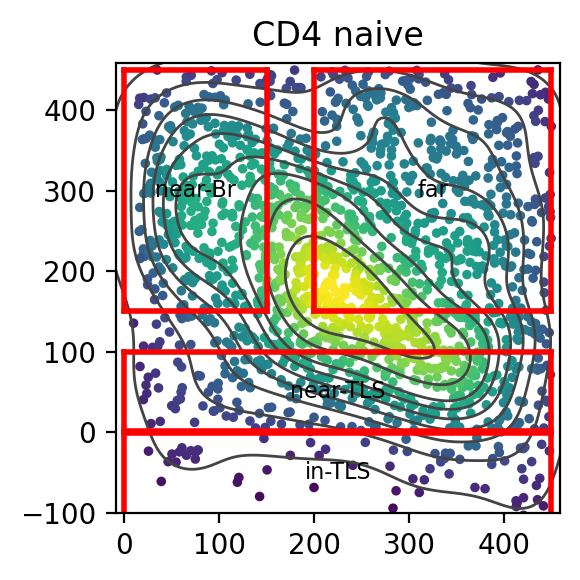

In [13]:
# x_axis = avg_distance_to_bronchi_zone, y_axis = distance_to_tls
sample_label = 'HDM_day3'
adata_plot = adata[adata.obs['sample_label'] == sample_label, :]
y_min = np.min(adata_plot.obs['distance_to_tls'])

gates = {
    'in-TLS': {'y_min':y_min, 'y_max': -1}, # in TLS
    'near-TLS':  {'y_min': 1, 'y_max': 100}, # close to TLS (any bronchi dist)
    'near-Br': {'x_max': 150, 'y_min': 150},      # close to bronchi, far from TLS
    'far':   {'x_min': 200, 'y_min': 150},      # far from both
}
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    # celltype='Th0',
    # celltype_col='label_fine',
    celltype='CD4 naive',
    celltype_col='label_medium',  
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells=5000
)
# plt.savefig(os.path.join(plot_out_dir, f"2D_density_CD4act_gates_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
p.show()

Using all cell types
cells in subset:  222870
Subsampling 222870 -> 5000 cells for the density


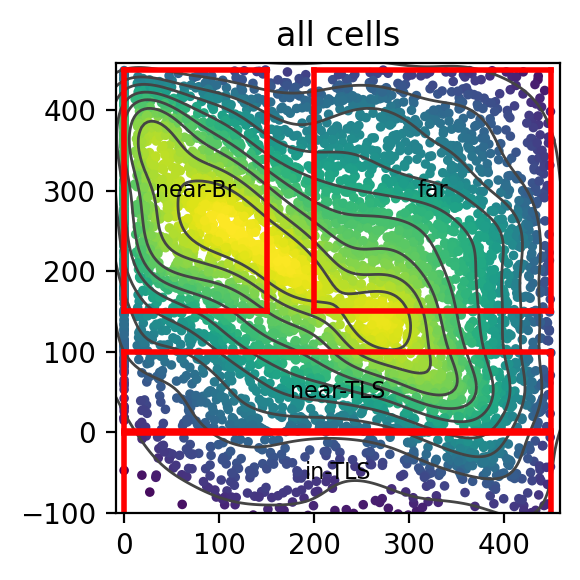

In [14]:
p = plot_celltype_density_2d(
    adata_plot,
    sample_label=[sample_label],
    celltype=None,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    gates=gates,
    x_clip=450,
    y_clip=450,
    point_size=24,
    max_cells = 5000,  
)

In [15]:
# Apply the gates to label every cell with the region it falls in.
# This writes adata.obs[region_col] for ALL cells (no clipping), so each
# cell gets a region using the same gate bounds drawn above.
adata = assign_spatial_region(
    adata,
    gates=gates,
    x_axis='avg_distance_to_bronchi_zone',
    y_axis='distance_to_tls',
    region_col='spatial_region',
)

adata.obs['spatial_region'].value_counts(dropna=False)

spatial_region
far           309532
near-Br       146590
unassigned     68503
near-TLS       47276
in-TLS         21336
Name: count, dtype: int64

## Plot cell type composition in these spatial regions

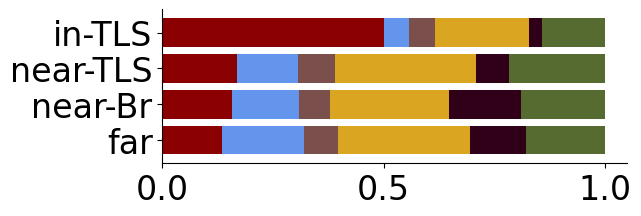

In [17]:
adata_plot = adata[adata.obs['spatial_region']!='unassigned', :]
ax1 = pu.zone_composition(adata_plot[adata_plot.obs['label_medium']=='CD4 act', :], 
                          label_col='label_fine', zone_col='spatial_region',
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = False, 
                       zone_ncell_filter = 50,
                       horizontal=True,
                       whitespace=0.8
                      )

ax1.figure.set_size_inches(6, 2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')  
ax1.legend_.remove()

## Spearman correlation of ligand expression with distance from TLS or distance from bronchi
- bin cells into 10 um bins on each distance axis and get mean expression per bin
- test spearman correlation

In [18]:
from scipy.stats import spearmanr


def _bh_fdr(pvals):
    """Benjamini-Hochberg FDR. NaNs are ignored and returned as NaN."""
    p = np.asarray(pvals, dtype=float)
    out = np.full(p.shape, np.nan)
    mask = ~np.isnan(p)
    pm = p[mask]
    m = len(pm)
    if m == 0:
        return out
    order = np.argsort(pm)
    q = pm[order] * m / np.arange(1, m + 1)
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    adj = np.empty(m)
    adj[order] = q
    out[mask] = adj
    return out


def binned_mean_expression(adata, genes, dist_col, bin_size=10,
                           dist_clip=None, min_cells_per_bin=10, layer=None):
    """Bin cells along `dist_col` into `bin_size`-um bins; return per-bin mean
    expression for each gene, plus the mean distance and cell count per bin.

    Parameters
    ----------
    dist_clip : float or (low, high), optional
        Restrict to a distance range before binning. A scalar is treated as the
        upper bound (low=0); a (low, high) pair clips on both sides. None = no clip.
    min_cells_per_bin : int
        Bins with fewer than this many cells are dropped (noisy means).
    layer : str, optional
        adata layer to read expression from; None uses adata.X.
    """
    genes = [g for g in genes if g in adata.var_names]
    ad = adata[:, genes]
    X = ad.layers[layer] if layer is not None else ad.X
    X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
    d = adata.obs[dist_col].to_numpy(dtype=float)

    keep = ~np.isnan(d)
    if dist_clip is not None:
        lo, hi = (0, dist_clip) if np.isscalar(dist_clip) else dist_clip
        keep &= (d >= lo) & (d <= hi)
    X, d = X[keep], d[keep]

    df = pd.DataFrame(X, columns=genes)
    df['_bin'] = np.floor(d / bin_size).astype(int)
    df['_dist'] = d

    grp = df.groupby('_bin')
    out = grp[genes].mean()
    out.insert(0, 'bin_dist', grp['_dist'].mean())
    out.insert(1, 'n_cells', grp.size())
    out = out[out['n_cells'] >= min_cells_per_bin].sort_values('bin_dist')
    return out


def spearman_expr_vs_distance(adata, genes, dist_col, bin_size=10,
                              dist_clip=None, min_cells_per_bin=10, layer=None):
    """Spearman correlation of per-bin mean expression vs distance, per gene.

    Returns a DataFrame (gene, rho, pval, padj, n_bins) sorted by rho.
    rho < 0 => expression decreases with distance (enriched near the structure).

    Parameters
    ----------
    dist_clip : float or (low, high), optional
        Restrict to a distance range before binning. A scalar is treated as the
        upper bound (low=0); a (low, high) pair clips on both sides. None = no clip.
    """
    binned = binned_mean_expression(
        adata, genes, dist_col, bin_size=bin_size, dist_clip=dist_clip,
        min_cells_per_bin=min_cells_per_bin, layer=layer,
    )
    x = binned['bin_dist'].to_numpy()
    genes = [g for g in genes if g in binned.columns]

    rows = []
    for g in genes:
        y = binned[g].to_numpy()
        if len(y) >= 3 and np.ptp(y) > 0:
            rho, p = spearmanr(x, y)
        else:
            rho, p = np.nan, np.nan
        rows.append((g, rho, p, len(y)))

    res = pd.DataFrame(rows, columns=['gene', 'rho', 'pval', 'n_bins'])
    res['padj'] = _bh_fdr(res['pval'].to_numpy())
    return res.sort_values('rho').reset_index(drop=True)

def plot_spearman_rho(results, top_n=10, figsize=(5, 6), jitter=0.08,
                      point_size=12, label_fontsize=6, label_offset=0.20,
                      random_state=0):
    """Strip plot of Spearman rho per gene for each distance axis.

    Parameters
    ----------
    results : dict {category_label: df}
        Each df is the output of `spearman_expr_vs_distance` (needs 'gene', 'rho').
        One x-column is drawn per entry, in dict order.
    top_n : int
        Number of lowest- and highest-rho genes to text-label per category.
    """
    rng = np.random.default_rng(random_state)
    cats = list(results.keys())

    # global y-range for consistent label spacing across columns
    all_rho = np.concatenate([results[c]['rho'].dropna().to_numpy() for c in cats])
    ymin, ymax = np.nanmin(all_rho), np.nanmax(all_rho)
    pad = 0.05 * (ymax - ymin)
    ylo, yhi = ymin - pad, ymax + pad
    min_gap = (yhi - ylo) / 45.0

    def _declutter(targets, gap, lo, hi):
        """Spread label y-positions to >= gap apart, recentered on their mean."""
        targets = np.asarray(targets, dtype=float)
        idx = np.argsort(targets)
        ys = targets[idx].copy()
        for i in range(1, len(ys)):
            if ys[i] - ys[i - 1] < gap:
                ys[i] = ys[i - 1] + gap
        ys += targets.mean() - ys.mean()          # keep near original cluster
        if ys[-1] > hi:
            ys -= ys[-1] - hi
        if ys[0] < lo:
            ys -= ys[0] - lo
        out = np.empty_like(ys)
        out[idx] = ys
        return out

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    for i, cat in enumerate(cats):
        df = results[cat].dropna(subset=['rho']).sort_values('rho')
        y = df['rho'].to_numpy()
        x = i + rng.uniform(-jitter, jitter, len(y))
        ax.scatter(x, y, s=point_size, color='0.7', alpha=0.7,
                   edgecolors='none', zorder=1)

        side = 'right' if i >= len(cats) / 2 else 'left'
        sgn = 1 if side == 'right' else -1
        lx = i + sgn * label_offset
        ha = 'left' if side == 'right' else 'right'

        # label lowest and highest rho genes (declutter each group separately)
        for grp in (df.head(top_n), df.tail(top_n)):
            ax.scatter([i] * len(grp), grp['rho'], s=point_size + 8,
                       color='black', zorder=2)
            ly = _declutter(grp['rho'].to_numpy(), min_gap, ylo, yhi)
            for (_, row), yl in zip(grp.iterrows(), ly):
                ax.annotate(row['gene'], xy=(i, row['rho']), xytext=(lx, yl),
                            fontsize=label_fontsize, va='center', ha=ha,
                            arrowprops=dict(arrowstyle='-', lw=0.4, color='0.6'))

    ax.axhline(0, color='black', lw=0.8, ls='--', zorder=0)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_xlim(-0.6, len(cats) - 0.4)
    ax.set_ylim(ylo, yhi)
    ax.set_ylabel('Spearman rho', fontsize=10)
    ax.grid(False)
    fig.tight_layout()
    return fig, ax


In [22]:
# select ligands in panel
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands = df_lr['ligand'].tolist()
ligands_panel = list(set(ligands) & set(adata.var.index))

In [30]:
df_lr[df_lr['ligand']=='Ccl19']

,Unnamed: 0,interaction_name,pathway_name,ligand,receptor,agonist,antagonist,co_A_receptor,co_I_receptor,evidence,annotation,interaction_name_2
653,CCL19_CCR7,CCL19_CCR7,CCL,Ccl19,Ccr7,NaN,NaN,NaN,NaN,KEGG: mmu04060,Secreted Signaling,Ccl19 - Ccr7
657,CCL19_ACKR4,CCL19_ACKR4,CCL,Ccl19,Ackr4,NaN,NaN,NaN,NaN,KEGG: mmu04060,Secreted Signaling,Ccl19 - Ackr4


In [20]:
sample_label = 'HDM_day3'
adata_corr = adata[adata.obs['sample_label'] == sample_label, :]

# distance from TLS
res_tls = spearman_expr_vs_distance(
    adata_corr, ligands_panel, dist_col='distance_to_tls',
    bin_size=10, dist_clip=(-150,150), min_cells_per_bin=10,
)

# distance from bronchi
res_bronchi = spearman_expr_vs_distance(
    adata_corr, ligands_panel, dist_col='avg_distance_to_bronchi_zone',
    bin_size=10, dist_clip=(0,150), min_cells_per_bin=10,
)

print('Top ligands enriched NEAR TLS (rho < 0):')
display(res_tls[res_tls['padj'] < 0.05].head(15))

print('Top ligands enriched NEAR bronchi (rho < 0):')
display(res_bronchi[res_bronchi['padj'] < 0.05].head(15))


Top ligands enriched NEAR TLS (rho < 0):


,gene,rho,pval,n_bins,padj
0,H2-Ab1,-0.989766,3.178881e-25,30,3.147093e-23
1,Icosl,-0.986652,1.286866e-23,30,6.255206e-22
2,H2-DMb2,-0.985762,3.159195e-23,30,6.255206e-22
3,Ptprc,-0.967075,3.523439e-18,30,2.683234e-17
4,Flt3l,-0.963960,1.225124e-17,30,8.663380e-17
5,Sell,-0.958621,8.200484e-17,30,4.510266e-16
6,Cd40lg,-0.942158,8.052687e-15,30,3.796267e-14
7,Ccl20,-0.934594,4.292316e-14,30,1.931542e-13
8,Thy1,-0.930590,9.618780e-14,30,3.967747e-13
9,Cd226,-0.903003,8.756329e-12,30,2.708989e-11


Top ligands enriched NEAR bronchi (rho < 0):


,gene,rho,pval,n_bins,padj
0,Scgb3a2,-0.989286,2.998934e-12,15,9.896483e-11
1,Calca,-0.792857,4.220772e-04,15,1.741068e-03
2,Nmb,-0.767857,8.293296e-04,15,3.040875e-03
3,Flt3l,-0.750000,1.280898e-03,15,4.226965e-03
4,C3,-0.742857,1.509489e-03,15,4.669981e-03
5,Lamc3,-0.742857,1.509489e-03,15,4.669981e-03
6,Il7,-0.710714,2.978995e-03,15,8.426300e-03
7,Tgfb3,-0.667857,6.509957e-03,15,1.696015e-02
8,Col1a1,-0.614286,1.483396e-02,15,3.581858e-02
9,Lama2,-0.610714,1.559283e-02,15,3.675453e-02


In [38]:
# results = {
#     'distance to TLS': res_tls,
#     'distance to bronchi': res_bronchi,
# }
# fig, ax = plot_spearman_rho(results, top_n=10)
# # fig.savefig(os.path.join(plot_out_dir, "spearman_rho_ligands_TLS_bronchi.pdf"),
# #             dpi=300, bbox_inches='tight', transparent=True)
# plt.show()


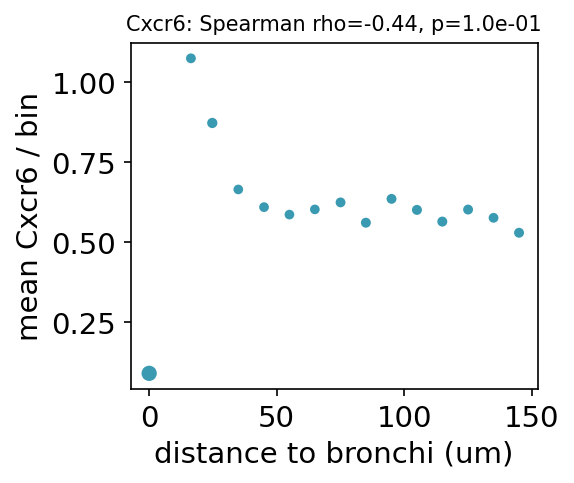

In [36]:
gene = 'Cxcr6'
b = binned_mean_expression(adata_corr, [gene], 'avg_distance_to_bronchi_zone',
                           bin_size=10, dist_clip=(0,150), min_cells_per_bin=10)
rho, p = spearmanr(b['bin_dist'], b[gene])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)
ax.scatter(b['bin_dist'], b[gene], s=b['n_cells'] / b['n_cells'].max() * 40,
           c='#3A9AB2')
ax.set_xlabel('distance to bronchi (um)')
ax.set_ylabel(f'mean {gene} / bin')
ax.set_title(f'{gene}: Spearman rho={rho:.2f}, p={p:.1e}', fontsize=10)
ax.grid(False)
plt.show()


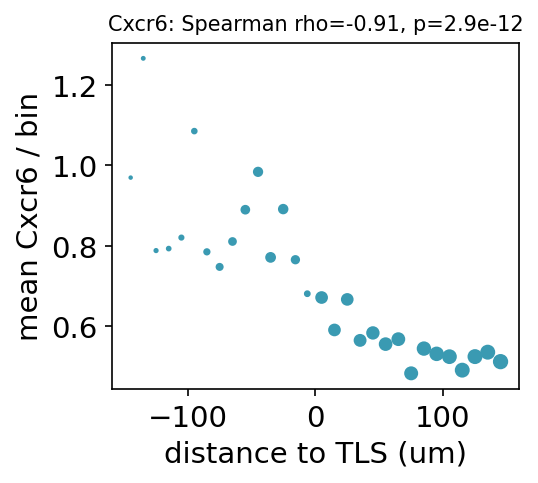

In [37]:
gene = 'Cxcr6'
b = binned_mean_expression(adata_corr, [gene], 'distance_to_tls',
                           bin_size=10, dist_clip=(-150,150), min_cells_per_bin=10)
rho, p = spearmanr(b['bin_dist'], b[gene])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)
ax.scatter(b['bin_dist'], b[gene], s=b['n_cells'] / b['n_cells'].max() * 40,
           c='#3A9AB2')
ax.set_xlabel('distance to TLS (um)')
ax.set_ylabel(f'mean {gene} / bin')
ax.set_title(f'{gene}: Spearman rho={rho:.2f}, p={p:.1e}', fontsize=10)
ax.grid(False)
plt.show()


## Ligand DE between spatial regions (independent of cell type)

In [27]:
importlib.reload(du)

<module 'de_utils' from '/home/workspace/spatial_tls_manuscript/utils/de_utils.py'>

Subset shape: (305278, 99) - no celltype subsetting
not subsetting by cell type
removing genes by expression threshold:  0.01
Unique DEGs before pval/lfc filter: 75
Unique DEGs after pval/lfc filter: 67


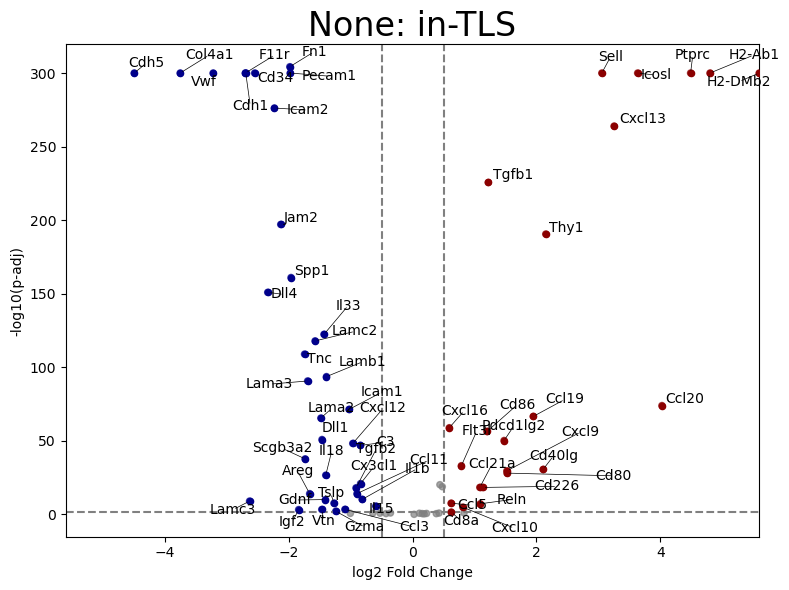

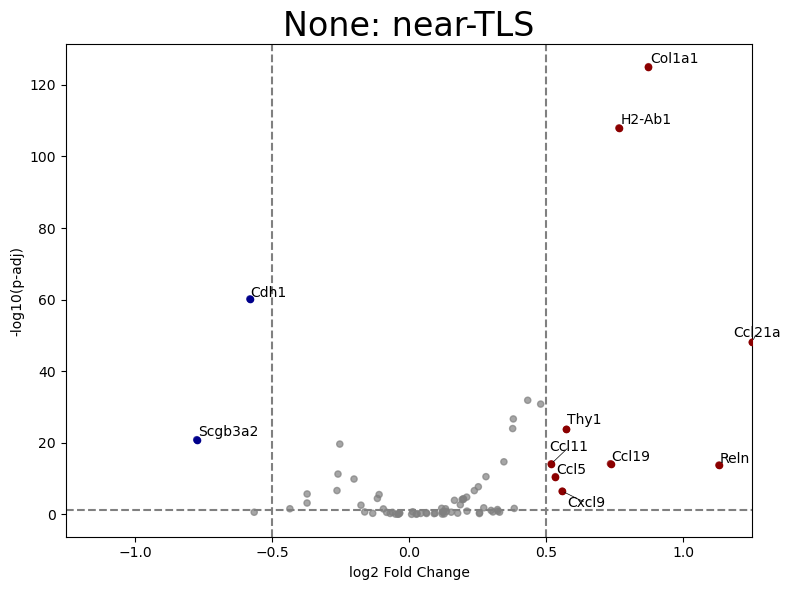

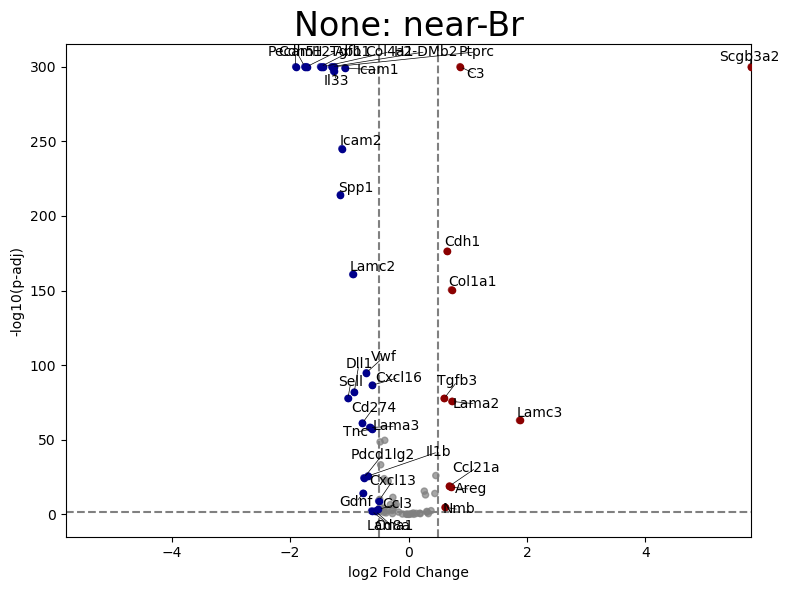

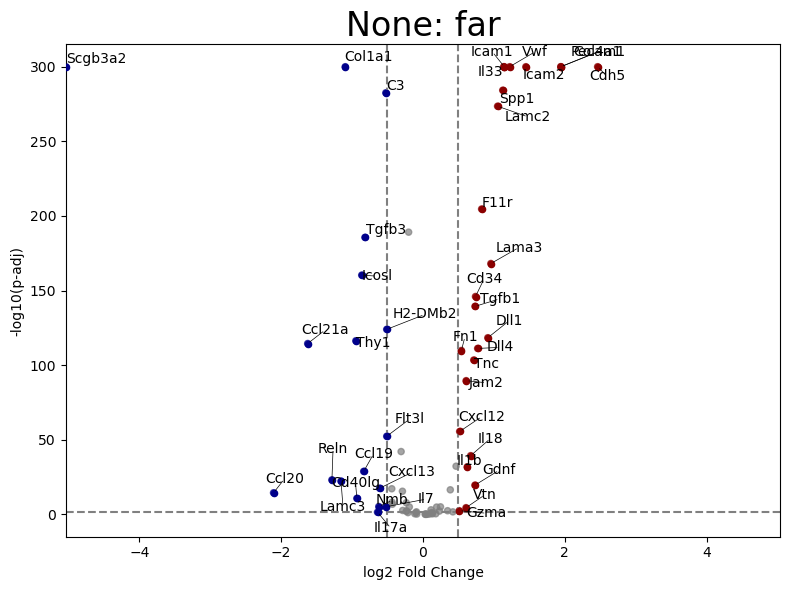

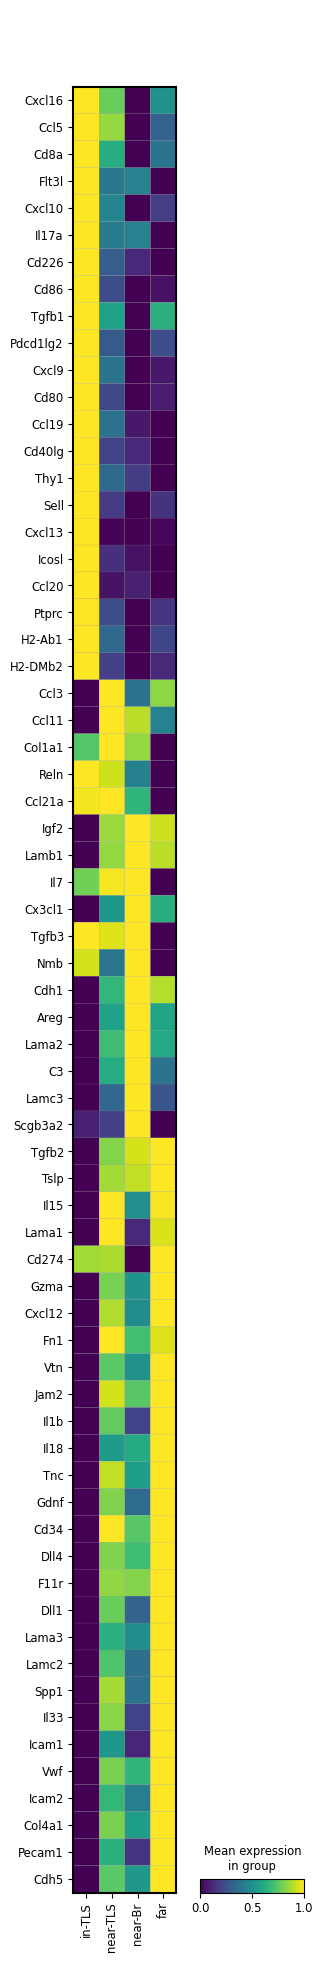

In [27]:
sample_label = 'HDM_day3'
zone_col = 'spatial_region'
zone_order=['in-TLS','near-TLS', 'near-Br','far'] 
    
adata_select = adata[adata.obs['sample_label']==sample_label, ligands_panel]
adata_select = adata_select[adata_select.obs[zone_col].isin(zone_order),:]
    
df_DEG, df_DEG_filt = du.run_zone_DE_analysis(
    adata=adata_select,
    celltype=None,
    celltype_col = None,
    zone_col = zone_col,
    zone_order=zone_order, 
    reference_zone='rest',
    lfc_cutoff=0.5,
    pval_cutoff=0.05,
    expression_threshold = 0.01,
)

In [28]:
df_DEG[df_DEG['names']=='Ccl11']

,names,logfoldchanges,pvals_adj,group
48,Ccl11,-0.897039,7.684239e-15,in-TLS
85,Ccl11,0.518795,7.210617e-15,near-TLS
161,Ccl11,0.443695,9.818461e-15,near-Br
284,Ccl11,-0.439607,6.077576e-18,far


In [25]:
df_DEG.to_csv('ligand_gate_DE.csv')

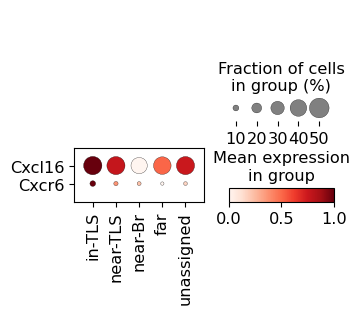

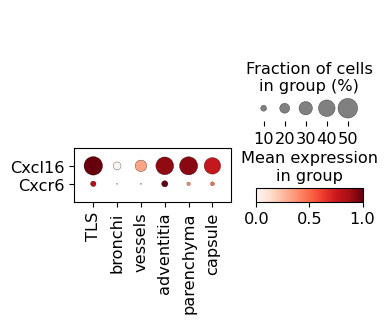

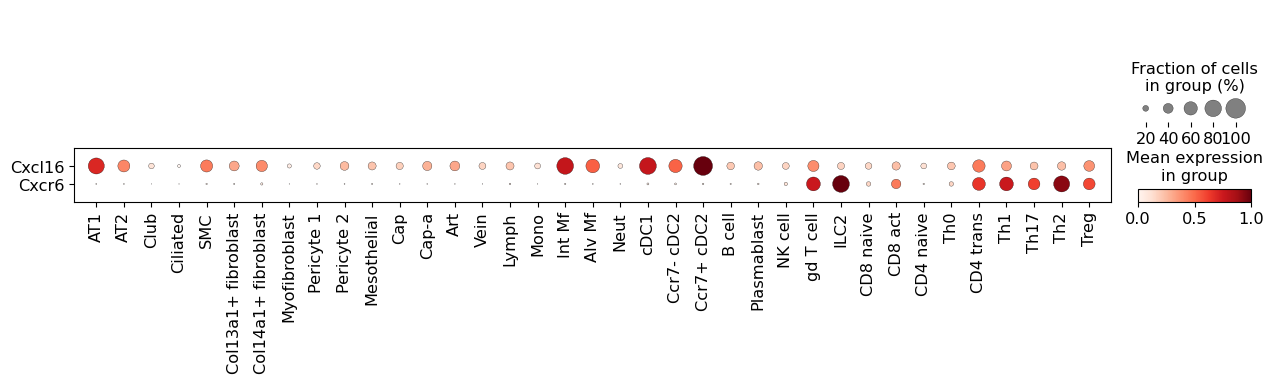

In [63]:
sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='spatial_region', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='zone_consol', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='label_fine', standard_scale = 'var', swap_axes=True)

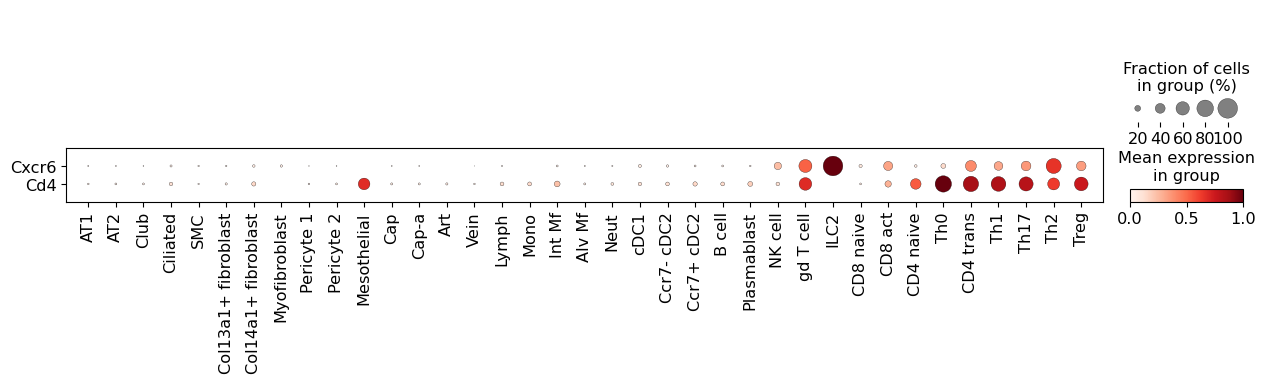

In [65]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(['in-TLS']),:]
sc.pl.dotplot(adata_select, var_names = ['Cxcr6','Cd4'], groupby='label_fine', standard_scale = 'var', swap_axes=True)

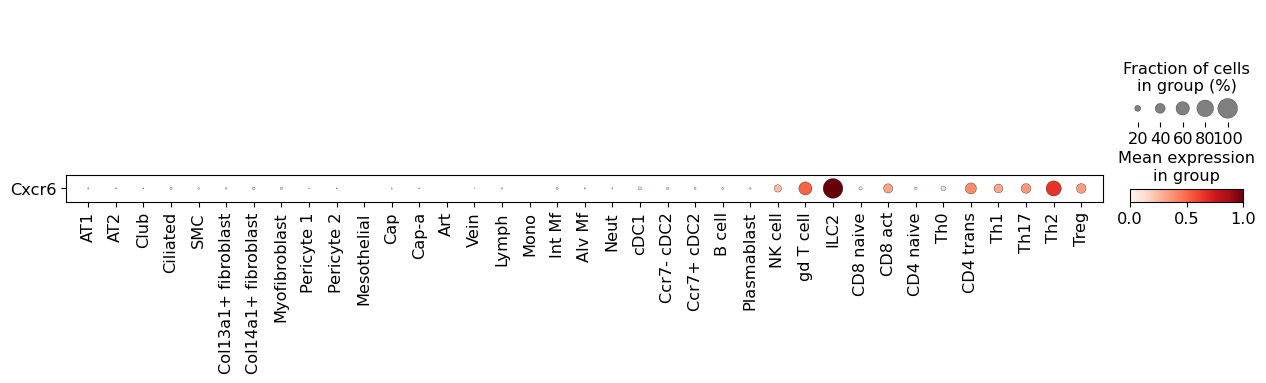

In [41]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['in-TLS'] 
ligands = ['Cxcr6']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

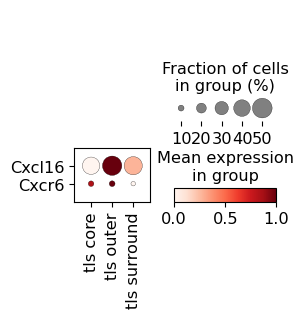

In [61]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
sc.pl.dotplot(adata_select, var_names = ['Cxcl16', 'Cxcr6'], groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)

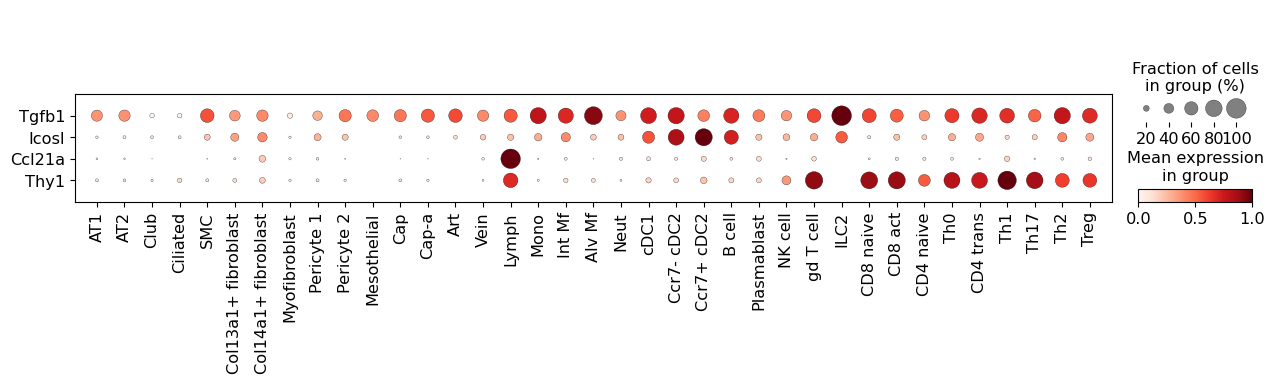

In [141]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['in-TLS'] 
inTLS_ligands = ['Tgfb1', 'Icosl', 'Ccl21a', 'Thy1']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

top cell types: ['AT2', 'Mesothelial', 'CD4 trans', 'Col14a1+ fibroblast', 'Pericyte 2']


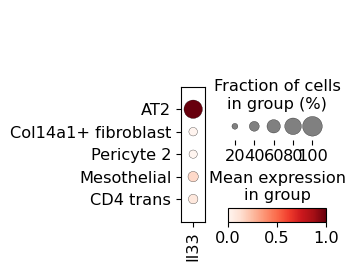

In [109]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region = ['far']
inregion_ligands = ['Il33']
top_n_celltypes = 5

adata_select = adata[adata.obs['sample_label'] == sample_label, :]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region), :]

# rank cell types by mean expression of the ligand set (within the region),
# keep the top N
expr = sc.get.obs_df(adata_select, keys=inregion_ligands + ['label_fine'])
mean_by_ct = expr.groupby('label_fine', observed=True)[inregion_ligands].mean()
top_celltypes = (mean_by_ct.mean(axis=1)
                 .sort_values(ascending=False)
                 .head(top_n_celltypes).index.tolist())
print('top cell types:', top_celltypes)

adata_top = adata_select[adata_select.obs['label_fine'].isin(top_celltypes), :].copy()
adata_top.obs['label_fine'] = adata_top.obs['label_fine'].cat.remove_unused_categories()

sc.pl.dotplot(adata_top, var_names=inregion_ligands, groupby='label_fine',
              standard_scale='var', swap_axes=False)


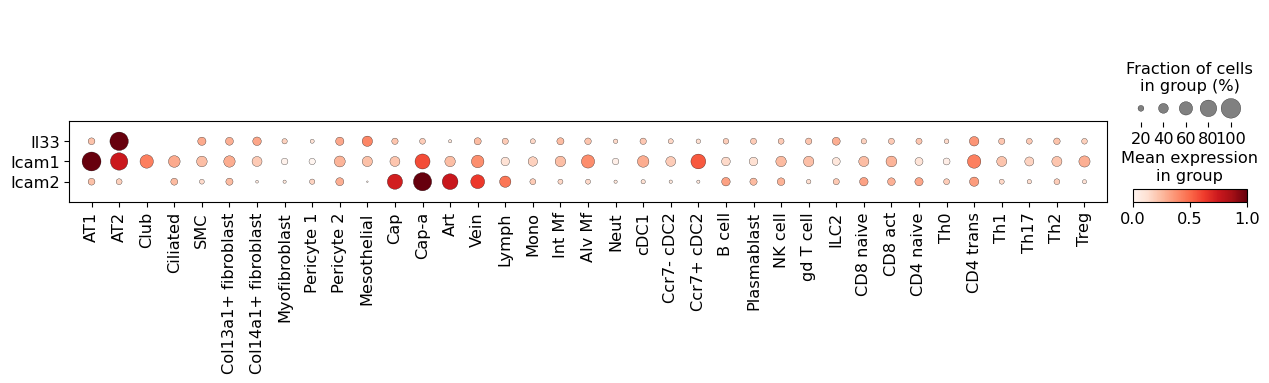

In [142]:
# unpack cell type expression of these DE ligands in each region
sample_label = 'HDM_day3'
region=['far'] 
inTLS_ligands = ['Il33', 'Icam1', 'Icam2']
    
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [102]:
# # unpack cell type expression of these DE ligands in each region
# sample_label = 'HDM_day3'
# region=['far'] 
# inTLS_ligands = ['Cxcr6']
    
# adata_select = adata[adata.obs['sample_label']==sample_label,:]
# adata_select = adata_select[adata_select.obs['spatial_region'].isin(region),:]
# print(adata_select.shape)
# sc.pl.dotplot(adata_select, var_names = inTLS_ligands, groupby='label_fine', standard_scale = 'var', swap_axes=True)

(2500.0, 4000.0)

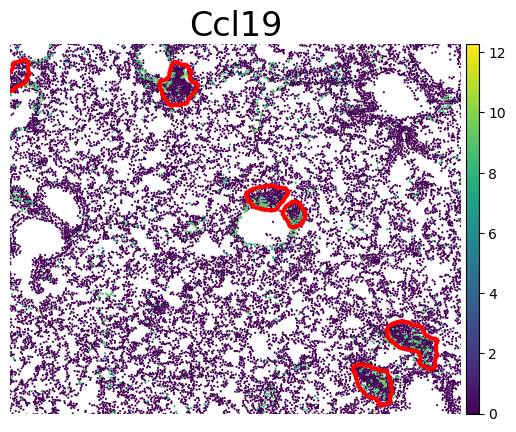

In [18]:
gene = 'Ccl19'
sample_label ='HDM_day3'
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = gene, 
                # color = 'zone_consol', palette = zone_consol_palette_mapped,
                # color = 'spatial_region',
                frameon=False, 
                size=10, 
                # legend_loc = 'none',
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='red', linewidth=3)

# plt.xlim([3500, 5500])
# plt.ylim([2500, 4500])
plt.xlim([3500, 5000])
plt.ylim([2500, 4000])
# plt.xlim([3830, 4160])
# plt.ylim([4320, 4650])
# plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_categories.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot gene expression in spatial regions

In [21]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1' ,
                     'Ccl19', 'Ccl21a'
]
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

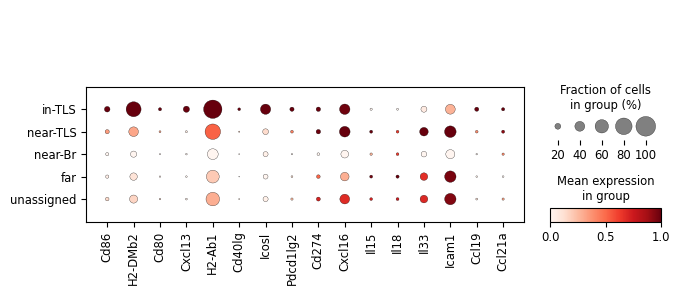

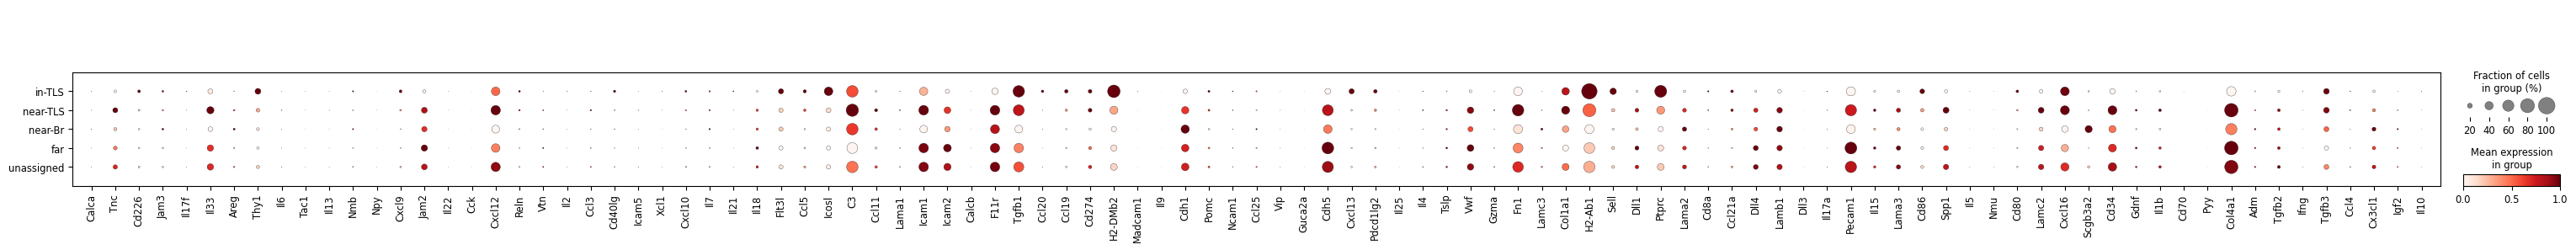

In [22]:



sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='spatial_region', standard_scale = 'var', swap_axes=False)
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='spatial_region', standard_scale = 'var', swap_axes=False)
# sc.pl.matrixplot(adata, var_names = ligands_highlight, groupby='spatial_region', standard_scale = 'var', swap_axes=False)

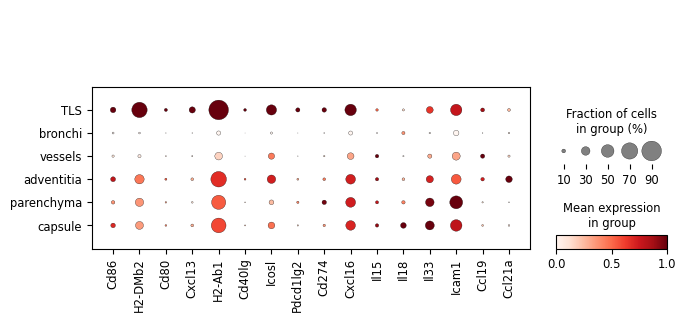

In [103]:
# all ligands
sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='zone_consol', standard_scale = 'var', swap_axes=False)

## 2D distance plots

In [150]:
# from scipy.spatial import KDTree
# from scipy.stats import gaussian_kde

# def scatter_with_gaussian_kde(ax, x, y, weights=None, s=2, **kwargs):
#     xy = np.vstack([x, y])
#     try:
#         z = gaussian_kde(xy, weights=weights)(xy)
#     except:
#         z = gaussian_kde(xy)(xy)

#     kwargs.setdefault('marker', '.')
#     ax.scatter(x, y, c=z, s=s, **kwargs)

# def distance_xy_kde(
#     adata: sc.AnnData,
#     sample_label: list[str],
#     x_axis: str,
#     y_axis: str,
#     key_name: str,
#     key_value: str = None,
#     gene_name: str = None,
#     signature_col: str = None, 
#     palette=None, 
#     x_clip=None,
#     y_clip=None,
#     figsize: tuple = None,
#     vline: float = None, 
#     hline: float = None,
#     point_size = 2,
# ):

#     fig = plt.figure(figsize=(3, 3), dpi=200)
    
#     # Subset by sample_label
#     adata = adata[adata.obs["sample_label"].isin(sample_label)]
    
#     if key_value:
#         print(f"Subset to '{key_name}' == '{key_value}'")
#         adata = adata[adata.obs[key_name] == key_value]
#     else:
#         print("Using all cells")

#     # Clip x and y axes
#     if x_clip:
#         print('Clipping x to', x_clip)
#         adata = adata[adata.obs[x_axis] <= x_clip, :]
#     if y_clip:
#         print('Clipping y to', y_clip)
#         adata = adata[adata.obs[y_axis] <= y_clip, :]

#     sub_adata = adata.copy()

#     if signature_col:
#         print('plotting signature')
#         gene_expr = sub_adata.obs[signature_col]
#         title = signature_col
#     else:
#         print('plotting gene expr')
#         gene_expr = sub_adata[:, gene_name].X.toarray().flatten() if hasattr(sub_adata[:, gene_name].X, "toarray") else sub_adata[:, gene_name].X.flatten()
#         gene_expr = np.nan_to_num(gene_expr)
#         title = gene_name
    
#     ax = fig.add_subplot(1, 1, 1)
    
     
#     # KDE scatter plot
#     scatter_with_gaussian_kde(
#         ax=ax,
#         x=sub_adata.obs[x_axis],
#         y=sub_adata.obs[y_axis],
#         s=point_size,
#         weights=(gene_expr - np.min(gene_expr)) ** 2,
#         cmap="viridis",
#     )

#     # KDE weighted by expression
#     sns.kdeplot(
#         data=sub_adata.obs,
#         x=x_axis,
#         y=y_axis,
#         ax=ax,
#         color="#444444",
#         linewidths=1,
#         weights=(gene_expr - np.min(gene_expr)) ** 2,
#         cmap="viridis",
#     )

#     # Add vline and hline if specified
#     if vline is not None:
#         # ax.axvline(x=vline, color='black', linestyle='--', linewidth=2)
#         ax.plot([vline, vline], [hline, y_clip], color='black', linestyle='--', linewidth=2)
#     if hline is not None:
#         ax.axhline(y=hline, color='black', linestyle='--', linewidth=2)


#     ax.set_xlim(-10,x_clip+10)
#     ax.set_ylim(-10,y_clip+10)
    
#     ax.set_xticks([0, x_clip])
#     ax.set_yticks([0, y_clip])
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])
#     # ax.set_xticklabels(['0', str(x_clip)], fontsize=16)
#     # ax.set_yticklabels(['0', str(y_clip)], fontsize=16)    
#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     ax.grid(False)

#     fig.tight_layout()
#     # plt.title(title, fontsize=20)
#     plt.title('')
    
#     return(plt)


In [20]:
from scipy.spatial import KDTree
from scipy.stats import gaussian_kde

def scatter_with_gaussian_kde(ax, x, y, weights=None, s=2, **kwargs):
    xy = np.vstack([x, y])
    try:
        z = gaussian_kde(xy, weights=weights)(xy)
    except:
        z = gaussian_kde(xy)(xy)

    kwargs.setdefault('marker', '.')
    ax.scatter(x, y, c=z, s=s, **kwargs)

def distance_xy_kde(
    adata: sc.AnnData,
    sample_label: list[str],
    gene_name: str = None,
    signature_col: str = None,
    x_axis: str = 'avg_distance_to_bronchi_zone',
    y_axis: str = 'distance_to_tls',
    celltype: str = None,
    celltype_col: str = 'label_fine',
    gates: dict = None,
    x_clip: float = 450,
    y_clip: float = 450,
    x_ticks: list = None,
    y_ticks: list = None,
    max_cells: int = None,
    random_state: int = 0,
    figsize: tuple = (3, 3),
    point_size: float = 2,
    show_gate_labels: bool = True,
    vline: float = None,
    hline: float = None,
    palette=None,
):
    """
    2D distance plot of gene-expression (or signature) density.

    Companion to `plot_celltype_density_2d`: same subsetting / clipping / gating
    parameters, but the KDE is weighted by `gene_name` expression (or a
    `signature_col` in obs) instead of plain cell density.
    """
    fig = plt.figure(figsize=figsize, dpi=200)

    # Subset by sample_label
    adata = adata[adata.obs["sample_label"].isin(sample_label)]

    # Optionally subset to a cell type (celltype=None -> use all cells)
    if celltype is not None:
        print(f"Subset to '{celltype_col}' == '{celltype}'")
        adata = adata[adata.obs[celltype_col] == celltype]
    else:
        print("Using all cells")

    # Clip x and y axes
    if x_clip:
        print('Clipping x to', x_clip)
        adata = adata[adata.obs[x_axis] <= x_clip, :]
    if y_clip:
        print('Clipping y to', y_clip)
        adata = adata[adata.obs[y_axis] <= y_clip, :]

    sub_adata = adata.copy()

    # Downsample before the KDE if there are too many cells. gaussian_kde
    # evaluates an O(n^2) pairwise density, so 300k+ cells is very slow and
    # memory-heavy; cap the number of points used for the plot.
    if max_cells is not None and sub_adata.n_obs > max_cells:
        print(f'Subsampling {sub_adata.n_obs} -> {max_cells} cells for the density')
        sub_adata = sc.pp.subsample(sub_adata, n_obs=max_cells, copy=True,
                                    random_state=random_state)

    if signature_col:
        print('plotting signature')
        gene_expr = sub_adata.obs[signature_col]
        title = signature_col
    else:
        print('plotting gene expr')
        gene_expr = sub_adata[:, gene_name].X.toarray().flatten() if hasattr(sub_adata[:, gene_name].X, "toarray") else sub_adata[:, gene_name].X.flatten()
        gene_expr = np.nan_to_num(gene_expr)
        title = gene_name

    ax = fig.add_subplot(1, 1, 1)


    # KDE scatter plot
    scatter_with_gaussian_kde(
        ax=ax,
        x=sub_adata.obs[x_axis],
        y=sub_adata.obs[y_axis],
        s=point_size,
        weights=(gene_expr - np.min(gene_expr)) ** 2,
        cmap="viridis",
    )

    # KDE weighted by expression
    sns.kdeplot(
        data=sub_adata.obs,
        x=x_axis,
        y=y_axis,
        ax=ax,
        color="#444444",
        linewidths=1,
        weights=(gene_expr - np.min(gene_expr)) ** 2,
        cmap="viridis",
    )



    # Add vline and hline if specified
    if vline is not None:
        # ax.axvline(x=vline, color='black', linestyle='--', linewidth=2)
        ax.plot([vline, vline], [hline, y_clip], color='black', linestyle='--', linewidth=2)
    if hline is not None:
        ax.axhline(y=hline, color='black', linestyle='--', linewidth=2)

    # # axis limits
    # xlim = (-10, x_clip + 10)
    # ylim = (-10, y_clip + 10)
    # axis limits with a small relative pad
    xpad = 0.02 * x_clip
    ypad = 0.02 * y_clip
    xlim = (-xpad, x_clip + xpad)
    # ylim = (-ypad, y_clip + ypad)
    ylim = (-100, y_clip + ypad)

    # overlay gates (same drawing as plot_celltype_density_2d); borders outside
    # the view limits are omitted / clipped to the axis
    if gates:
        _draw_gates(ax, gates, x_clip, y_clip,
                    show_labels=show_gate_labels, xlim=xlim, ylim=ylim)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    # ticks: label chosen distances if provided, else blank ticks at the extremes
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(t) for t in x_ticks])
    # else:
    #     ax.set_xticks([0, x_clip])
    #     ax.set_xticklabels([])
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([str(t) for t in y_ticks])
    # else:
    #     ax.set_yticks([0, y_clip])
    #     ax.set_yticklabels([])

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)

    fig.tight_layout()
    # plt.title(title, fontsize=20)
    plt.title(gene_name)

    return(plt)


HDM_day3
Subset to 'label_medium' == 'CD4 act'
Clipping x to 450
Clipping y to 450
plotting gene expr
Subset to 'label_medium' == 'CD4 act'
Clipping x to 450
Clipping y to 450
plotting gene expr
Subset to 'label_medium' == 'CD4 act'
Clipping x to 450
Clipping y to 450
plotting gene expr
Subset to 'label_medium' == 'CD4 act'
Clipping x to 450
Clipping y to 450
plotting gene expr


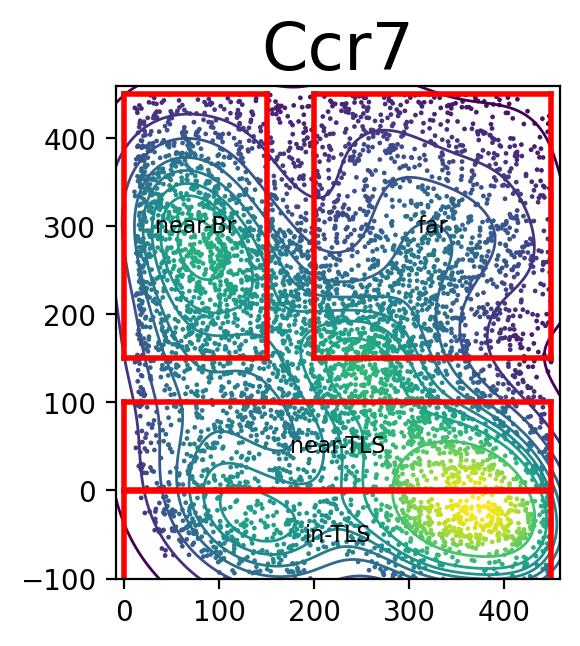

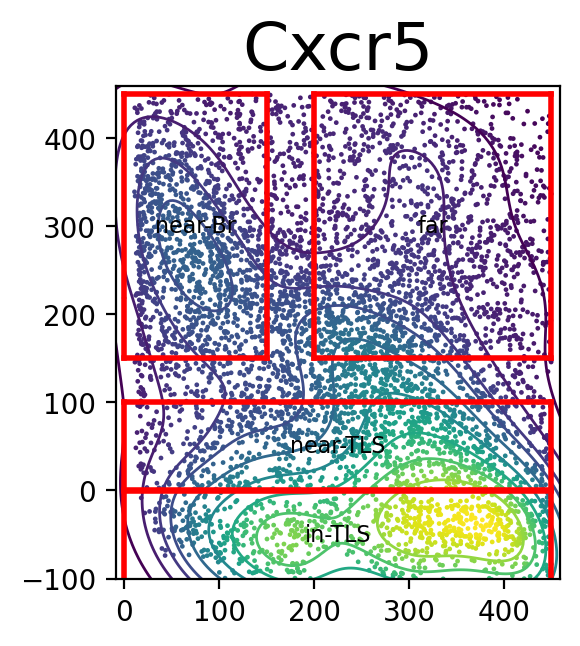

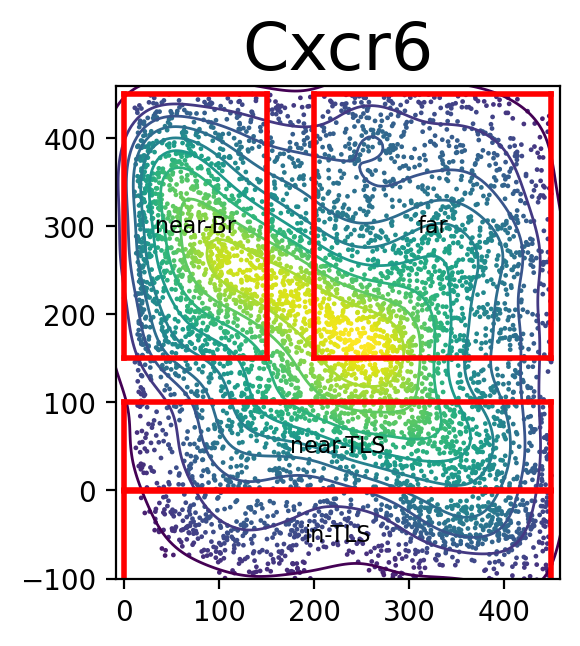

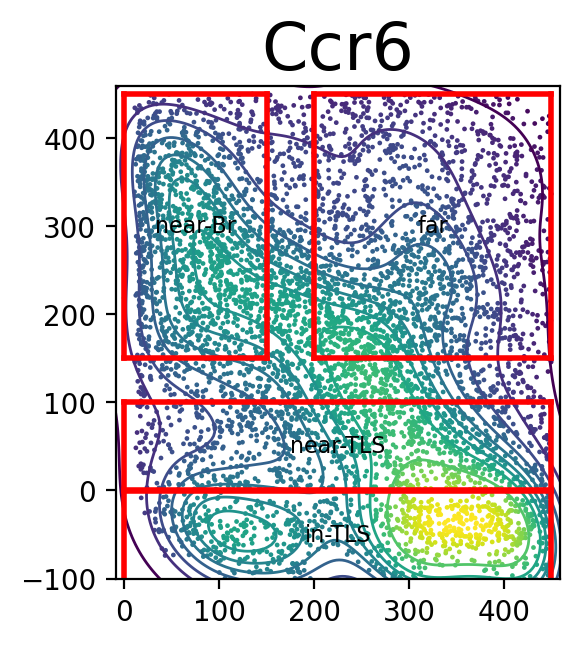

In [21]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
# for gene_name in ['Ccr7', 'Tgfbr1', 'Tgfbr2','Icos', 'Pdcd1' ]:
for gene_name in ['Ccr7', 'Cxcr5', 'Cxcr6','Ccr6']:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone',
                        y_axis = 'distance_to_tls',
                        gene_name = gene_name,
                    celltype_col = 'label_medium',
                    celltype = 'CD4 act',
                   x_clip = 450,
                   y_clip= 450,
                        gates = gates
                       )


HDM_day3
Using all cells
Clipping x to 450
Clipping y to 450
Subsampling 222870 -> 5000 cells for the density
plotting gene expr
Using all cells
Clipping x to 450
Clipping y to 450
Subsampling 222870 -> 5000 cells for the density
plotting gene expr
Using all cells
Clipping x to 450
Clipping y to 450
Subsampling 222870 -> 5000 cells for the density
plotting gene expr


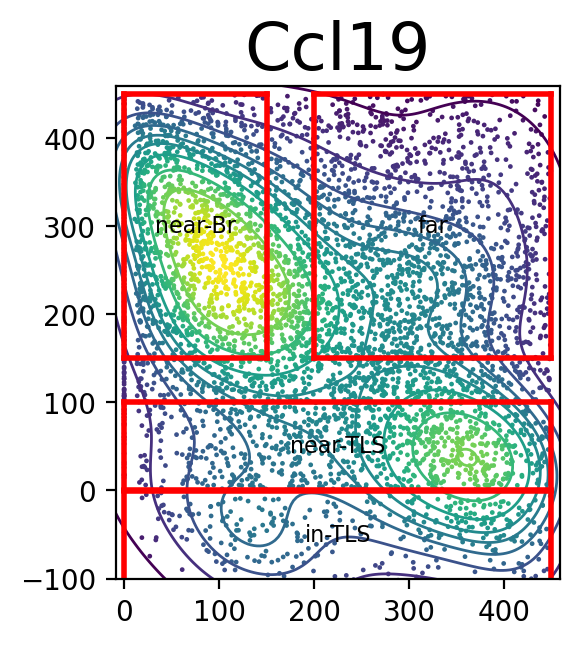

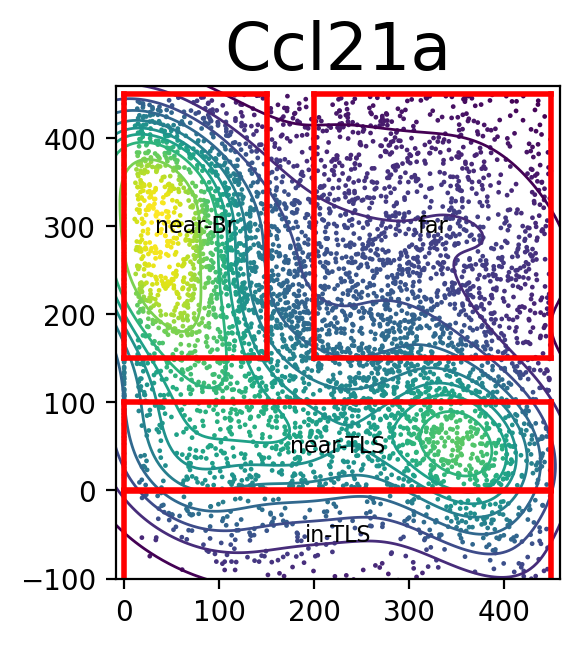

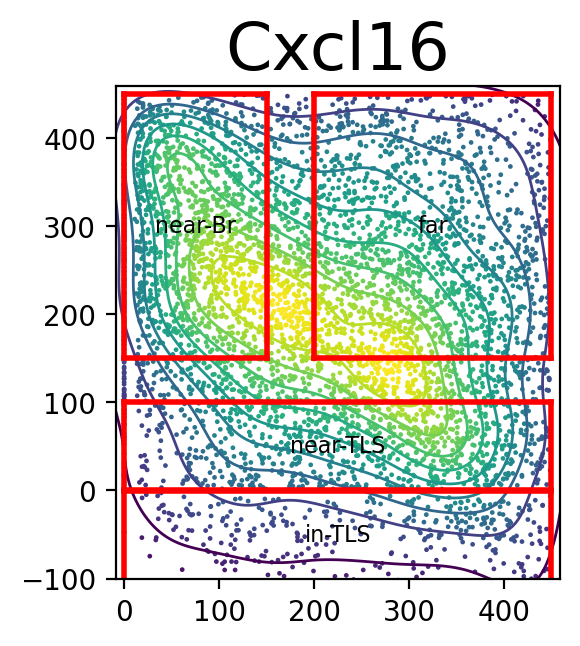

In [15]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
for gene_name in ['Ccl19', 'Ccl21a','Cxcl16']:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone',
                        y_axis = 'distance_to_tls',
                        gene_name = gene_name,
                   x_clip = 450,
                   y_clip= 450,
                        gates = gates, 
                        max_cells=5000
                       )
    # plt.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}.pdf"), dpi=300, bbox_inches='tight', transparent=True)


In [ ]:
# sample_label = 'HDM_day3'
# print(sample_label)
# adata_plot = adata[adata.obs['sample_label']==sample_label, :]
# adata_plot_cd4 = adata_plot[adata_plot.obs['label_medium']=='CD4 act', :]
# adata_plot_cd4.shape

In [ ]:
# sample_label = 'HDM_day3'
# print(sample_label)
# adata_plot = adata[adata.obs['sample_label']==sample_label, :]
# for gene_name in ['Gata3', 
#                   'Il1rl1', 'Klrg1',
#                   'Tcf7', 'Slamf6', 'Ccr7',
#                  ]:
#     p = distance_xy_kde(adata_plot,
#         sample_label=[sample_label],
#         x_axis = 'avg_distance_to_bronchi_zone',
#         y_axis = 'distance_to_tls',
#         gene_name = gene_name,
#         key_name = 'label_medium',
#         key_value = 'CD4 act',
#         x_clip = 450,
#         y_clip= 450,
#         vline = 150, hline = 100,
#         point_size = 24
#                        )
#     # plt.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
#     plt.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}.png"), dpi=300, bbox_inches='tight', transparent=True)


### Distance quadrant gene expression heatmap

In [ ]:
def quantify_quadrant_expression(adata, 
                                 x_axis = 'avg_distance_to_bronchi_zone',
                                 y_axis = 'distance_to_tls',
                                 x_clip = 450, y_clip = 450,
                                 # x_clip=None, y_clip=None,
                                 x_threshold = 150, y_threshold = 100):
    
    adata = adata.copy()

    # Clip x and y axes
    if x_clip:
        print('Clipping x to', x_clip)
        adata = adata[adata.obs[x_axis] <= x_clip, :]
    if y_clip:
        print('Clipping y to', y_clip)
        adata = adata[adata.obs[y_axis] <= y_clip, :]
        
    quadrant_order = ['near-bronchi (B)', 'parenchyma (P)', 'near-TLS (T)']
    adata.obs['spatial_quadrant']= 'none'
    adata.obs.loc[(adata.obs[x_axis] > x_threshold) & (adata.obs[y_axis] > y_threshold), 'spatial_quadrant'] = 'parenchyma (P)'
    adata.obs.loc[adata.obs[y_axis] < y_threshold, 'spatial_quadrant'] = 'near-TLS (T)'
    adata.obs.loc[(adata.obs[x_axis] < x_threshold) & (adata.obs[y_axis] > y_threshold), 'spatial_quadrant'] = 'near-bronchi (B)'
    adata.obs['spatial_quadrant'] = pd.Categorical(adata.obs['spatial_quadrant'], categories=quadrant_order, ordered=True)
    return(adata) 

In [ ]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[adata_plot.obs['label_medium']=='CD4 act', :]

adata_plot = quantify_quadrant_expression(adata_plot)

print(adata_plot.shape)
sc.pl.matrixplot(adata_plot, var_names=['Gata3', 'Il1rl1', 'Klrg1', 'Tcf7', 'Slamf6', 'Ccr7'], groupby='spatial_quadrant', 
                 standard_scale='var', 
                 show=False
                )
plt.savefig(os.path.join(plot_out_dir, "spatial_quadrant_gene_matrixplot.pdf"), dpi=300, bbox_inches='tight', transparent=True)

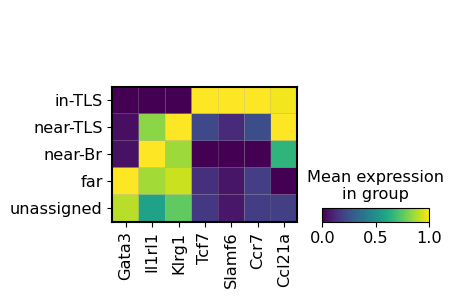

In [180]:
sc.pl.matrixplot(adata_plot, var_names=['Gata3', 'Il1rl1', 'Klrg1', 'Tcf7', 'Slamf6', 'Ccr7', 'Ccl21a'], groupby='spatial_region', 
                 standard_scale='var', 
                )

## Plot zones and distance in space

(4200.0, 4900.0)

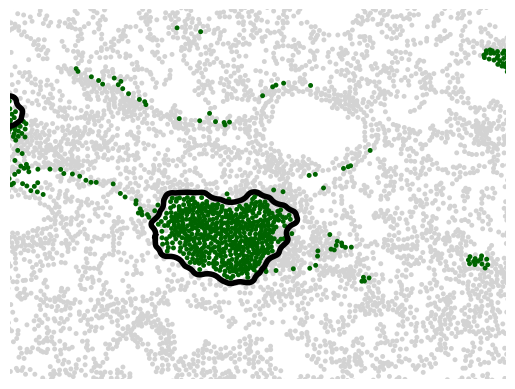

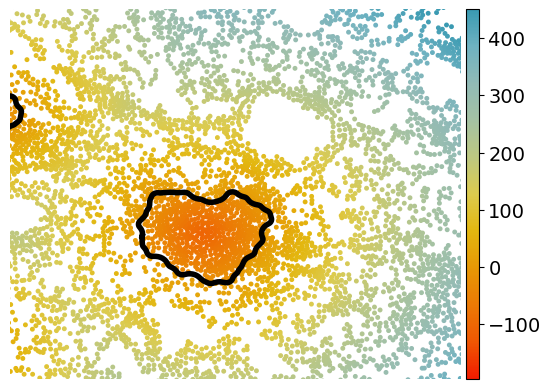

In [106]:
sample_label = 'HDM_day3'
adata_d3 = adata[adata.obs['sample_label'] == sample_label, :]
adata_plot = adata_d3.copy()
adata_plot.obs['zone_consol_temp'] = adata_plot.obs['zone_consol'].copy()
adata_plot.obs.loc[adata_plot.obs['zone_consol'] != 'TLS', 'zone_consol_temp'] = np.nan
sc.pl.embedding(adata_plot, basis='spatial', color='zone_consol_temp',
                palette = zone_consol_palette_mapped,
                frameon=False, 
                size=50, 
                title = '',
                legend_loc = 'none',
                show=False)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
bronchi_poly = joblib.load(os.path.join(dist_out_dir, 'bronchi_poly_' + sample_label + '.pkl'))
vessels_poly = joblib.load(os.path.join(dist_out_dir, 'vessels_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)
   
plt.xlim([3700, 4400])
plt.ylim([4200, 4900])
# plt.savefig(os.path.join(plot_out_dir, "zone_day3_tls_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

fig = sc.pl.embedding(adata_d3, basis='spatial', 
                # color='avg_distance_to_TLS_zone',
                color = 'distance_to_tls',
                cmap = colormap_r,
                vmax=450,
                frameon=False, 
                size=50, 
                title = '',
                # colorbar_loc = None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
bronchi_poly = joblib.load(os.path.join(dist_out_dir, 'bronchi_poly_' + sample_label + '.pkl'))
vessels_poly = joblib.load(os.path.join(dist_out_dir, 'vessels_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)
        
plt.xlim([3700, 4400])
plt.ylim([4200, 4900])
# plt.savefig(os.path.join(plot_out_dir, "distance_day3_tls_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
adata_plot = adata_d3.copy()
adata_plot.obs['zone_consol_temp'] = adata_plot.obs['zone_consol'].copy()
adata_plot.obs.loc[adata_plot.obs['zone_consol'] != 'bronchi', 'zone_consol_temp'] = np.nan
sc.pl.embedding(adata_plot, basis='spatial', color='zone_consol_temp',
                palette = zone_consol_palette_mapped,
                frameon=False, 
                size=50, 
                title = '',
                legend_loc = 'none',
                show=False)
    
plt.xlim([3150, 3900])
plt.ylim([2850, 3600])
plt.savefig(os.path.join(plot_out_dir, "zone_day3_bronchi_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

fig = sc.pl.embedding(adata_d3, basis='spatial', color='avg_distance_to_bronchi_zone',
                cmap = colormap_r,
                vmax=450,
                frameon=False, 
                size=50, 
                title = '',
                colorbar_loc = None,
                show=False, return_fig=True)
    
plt.xlim([3200, 3900])
plt.ylim([2900, 3600])
plt.savefig(os.path.join(plot_out_dir, "distance_day3_bronchi_zoom.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot 2D distances - ligand expression in all cells

In [ ]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = sc.pp.subsample(adata_plot, n_obs=10000, copy=True)
for gene_name in ['Cxcl13', 'Ccl21a','Ccl19', 
                  'Tgfb1', 'Il33', 
                  'Cxcl16'
                 ]:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone',
                        # y_axis = 'avg_distance_to_TLS_zone',
                         y_axis = 'distance_to_tls',
                        gene_name = gene_name,
                    key_name = 'label_medium',
                    key_value = None,
                   x_clip = 450,
                   y_clip= 450,
                        vline = 150, hline = 100
                       )
    p
    plt.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}_allcells_cyto.pdf"), dpi=300, bbox_inches='tight', transparent=True)


In [ ]:
# Run on larger number of cells - this will take awhile

import time

start = time.time()

sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = sc.pp.subsample(adata_plot, n_obs=50000, copy=True)
for gene_name in ['Ccl19','Il33',
                  # 'Cd274', 'Pdcd1lg2'
                 ]:
    p = distance_xy_kde(adata_plot,
                    sample_label=[sample_label],
                    x_axis = 'avg_distance_to_bronchi_zone',
                        # y_axis = 'avg_distance_to_TLS_zone',
                        y_axis = 'distance_to_tls',
                        gene_name = gene_name,
                    key_name = 'label_medium',
                    key_value = None,
                   x_clip = 450,
                   y_clip= 450,
                        vline = 150, hline = 100,
                        point_size = 2
                       )
    # p
    # p.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}_allcells_cyto_50k_{sample_label}.pdf"), dpi=300, bbox_inches='tight', transparent=True)
    p.savefig(os.path.join(plot_out_dir, f"2D_{gene_name}_allcells_cyto_50k_{sample_label}.png"), dpi=300, bbox_inches='tight', transparent=True)


end = time.time()
duration = (end - start) / 60
print(f"{duration:.2f} minutes")

### Check which cells are expressing these ligands

In [ ]:
sc.pl.matrixplot(adata, var_names = ['Cxcl13', 'Ccl21a','Ccl19', 'Tgfb1', 'Il33'], groupby='label_fine', standard_scale = 'var', swap_axes=True)

In [ ]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()